In [1]:

!pip install ocrmypdf pypdf PdfReader pdfplumber pandas pymupdf pdf2image pytesseract pdf2image openpyxl


In [2]:
import os
import glob
import re
import ocrmypdf
import pdfplumber
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
import seaborn as sns
import numpy as np
from pdf2image import convert_from_path
import pytesseract
from pypdf import PdfReader
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

In [3]:
ghg_2022 = pd.read_excel("/Users/noracook/sustainability_projects/checkerspot/ghg-emission-factors-hub-2022.xlsx")
ghg_2023 = pd.read_excel("/Users/noracook/sustainability_projects/checkerspot/ghg-emission-factors-hub-2023.xlsx")
ghg_2024 = pd.read_excel("/Users/noracook/sustainability_projects/checkerspot/ghg-emission-factors-hub-2023.xlsx")

/opt/anaconda3/lib/python3.11/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")
/opt/anaconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/opt/anaconda3/lib/python3.11/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")
/opt/anaconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/opt/anaconda3/lib/python3.11/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")
/opt/anaconda3/lib/python3.11/site-pa

## Scope 1 Emmisions

#### Alameda Natural Gas Usage

In [4]:
# Directory path configurations
pdf_directory = "/Users/noracook/sustainability_projects/checkerspot/Alameda_Nat gas only_PG&E_2023"  
pdf_pattern = os.path.join(pdf_directory, "*.[pP][dD][fF]")

# FIX: Parentheses () now ONLY wrap the numeric part. 
# It requires "Therms" to be there, but won't include it in match_str.
pattern = r"(\d{1,3}(?:,\d{3})*\.0{6})\s+Therms"

parsed_rows = []

# Loop through all matching PDFs found in the directory
for pdf_path in glob.glob(pdf_pattern):
    base_name = os.path.basename(pdf_path)
    
    # Keep unique names per billing cycle (using 6 characters per your original code)
    file_prefix = re.sub(r'\.pdf$', '', base_name, flags=re.IGNORECASE).replace(' ', '_')
    short_prefix = file_prefix[:6].strip('_') 
    variable_name = f"{short_prefix}"
    
    print(f"Visually scanning {base_name} via OCR...")
    
    try:
        # 1. Convert PDF pages visually into sharp high-resolution images (300 DPI)
        pages = convert_from_path(pdf_path, dpi=300)
        
        full_text = ""
        # 2. Extract visual text page-by-page
        for page_image in pages:
            page_text = pytesseract.image_to_string(page_image)
            if page_text:
                full_text += page_text + "\n"
        
        # Flatten ALL whitespaces into simple spaces for reliable regex matching
        full_text = re.sub(r'\s+', ' ', full_text)
        
        # Find all structural therm matches
        matches = re.findall(pattern, full_text, re.IGNORECASE)
        
        # Deduplicate values found in this bill
        unique_floats = []
        for match_str in matches:
            clean_match = float(match_str.replace(",", ""))
            if clean_match not in unique_floats:
                unique_floats.append(clean_match)
        
        # FIX: Extracts the raw number out of the list container. 
        # If no match is found, it falls back to your default number 9.
        total_therms = unique_floats[0] if unique_floats else 9
            
        # Set standalone dynamic global variable fallback
        globals()[variable_name] = total_therms
        
        # Append data as a dictionary row
        parsed_rows.append({
            "variable_name": variable_name,
            "therms_value": total_therms
        })
        
    except Exception as e:
        print(f"Error processing {short_prefix}: {e}")

# --- CONVERT TO DATAFRAME & PRINT ---
df_therms_al = pd.DataFrame(parsed_rows)
df_therms_al


Visually scanning 231126 PG&E Bill Period 10.25.23-11.22.23 $3,434.59.pdf via OCR...
Visually scanning 230525 PG&E Bill Period 04.26.2023-05.24.2023 $2,596.95.pdf via OCR...
Visually scanning 230823 PG&E Bill Period 7.26.23-8.23.23 $267.31.pdf via OCR...
Visually scanning 230726 PG&E Bill Period 06.24.2023-07.25.2023 $1,316.93.pdf via OCR...
Visually scanning 231224 PG&E Bill Period 11.23.23-12.22.23 $7,777.74.pdf via OCR...
Visually scanning 230625 PG&E Bill Period 05.25.2023-06.23.2023 $1,791.26.pdf via OCR...
Visually scanning 230224 PG&E Bill Period 01.25.2023-02.23.2023 $13,880.52.pdf via OCR...
Visually scanning 240125 PG&E Bill Period 12.23.23-1.24.24 $11,434.76.pdf via OCR...
Visually scanning 231025 PG&E Bill Period 9.23.23-10.24.23 $768.60.pdf via OCR...
Visually scanning 230924 PG&E Bill Period 8.24.23-9.22.23 $372.99.pdf via OCR...
Visually scanning 230125 PG&E Bill Period 12.23.2022-12.31.2022 $13,433.24.pdf via OCR...
Visually scanning 221223 PG&E Bill Period 11.23.2022-1

,variable_name,therms_value
0,231126,1767.0
1,230525,2100.0
2,230823,149.0
3,230726,956.0
4,231224,3645.0
5,230625,1392.0
6,230224,5319.0
7,240125,5219.0
8,231025,414.0
9,230924,204.0


In [5]:
df_therms_al

,variable_name,therms_value
0,231126,1767.0
1,230525,2100.0
2,230823,149.0
3,230726,956.0
4,231224,3645.0
5,230625,1392.0
6,230224,5319.0
7,240125,5219.0
8,231025,414.0
9,230924,204.0


In [6]:
# change the invoice_prefix to a date
df_therms_al['variable_name'] = pd.to_datetime(df_therms_al['variable_name'], format='%y%m%d')
df_therms_al = df_therms_al.rename(columns={"variable_name":"date"})
df_therms_al

,date,therms_value
0,2023-11-26,1767.0
1,2023-05-25,2100.0
2,2023-08-23,149.0
3,2023-07-26,956.0
4,2023-12-24,3645.0
5,2023-06-25,1392.0
6,2023-02-24,5319.0
7,2024-01-25,5219.0
8,2023-10-25,414.0
9,2023-09-24,204.0


In [7]:
df_therms_al = df_therms_al.sort_values(by="date")
df_therms_al

,date,therms_value
11,2022-12-23,5812.0
10,2023-01-25,5515.0
6,2023-02-24,5319.0
13,2023-03-26,5227.0
12,2023-04-26,3750.0
1,2023-05-25,2100.0
5,2023-06-25,1392.0
3,2023-07-26,956.0
2,2023-08-23,149.0
9,2023-09-24,204.0


In [8]:
#convert therms to mmbtu


numeric_cols = df_therms_al.select_dtypes(include=['float']).columns
df_therms_al[numeric_cols] = df_therms_al[numeric_cols] * 0.1

df_dk_al = df_therms_al
df_dk_al = df_dk_al.rename(columns={"therms_value":"dk_value"})
df_dk_al

,date,dk_value
11,2022-12-23,581.2
10,2023-01-25,551.5
6,2023-02-24,531.9
13,2023-03-26,522.7
12,2023-04-26,375.0
1,2023-05-25,210.0
5,2023-06-25,139.2
3,2023-07-26,95.6
2,2023-08-23,14.9
9,2023-09-24,20.4


In [9]:

# Directory path configurations
pdf_directory = "/Users/noracook/sustainability_projects/checkerspot/SLC_NAT Gas_DE"  
pdf_pattern = os.path.join(pdf_directory, "*.[pP][dD][fF]")

# FIX: Pattern explicitly matches CCF, a space, 6 decimals, a space, and groups your 1-decimal target
pattern = r"CCF\s+\d+\.\d{6,7}\s+(\d+(?:\.\d+)?)"

parsed_rows = []

# Loop through all matching PDFs found in the directory
for pdf_path in glob.glob(pdf_pattern):
    base_name = os.path.basename(pdf_path)
    
    # Keep unique names per billing cycle (using 6 characters per your original code)
    file_prefix = re.sub(r'\.pdf$', '', base_name, flags=re.IGNORECASE).replace(' ', '_')
    short_prefix = file_prefix[:6].strip('_') 
    variable_name = f"{short_prefix}"
    
    print(f"Visually scanning {base_name} via OCR...")
    
    try:
        # Convert PDF pages visually into sharp high-resolution images (300 DPI)
        pages = convert_from_path(pdf_path, dpi=300)
        
        full_text = ""
        # Extract visual text page-by-page
        for page_image in pages:
            page_text = pytesseract.image_to_string(page_image)
            if page_text:
                full_text += page_text + "\n"
        
        # Flatten ALL whitespaces into simple spaces for reliable regex matching
        full_text = re.sub(r'\s+', ' ', full_text)
        
        # Find all structural DTH matches using the updated pattern
        matches = re.findall(pattern, full_text, re.IGNORECASE)
        
        # Deduplicate values found in this bill
        unique_floats = []
        for match_str in matches:
            clean_match = float(match_str.replace(",", ""))
            if clean_match not in unique_floats:
                unique_floats.append(clean_match)

        total_dk = unique_floats
        
        # Fallback list value if no matches are found at all
        #if not unique_floats:
           # unique_floats = "NaN"
            
        # Set the standalone dynamic global variable fallback to the whole list
        globals()[variable_name] = total_dk
        
        # Initialize the row dictionary with the file identity
        row_data = {"variable_name": variable_name}
        
        # FIX: Maps to multiple sequential columns prefixed with 'slc_site_'
        for index, value in enumerate(total_dk, start=1):
            column_name = f"slc_site_{index}"
            row_data[column_name] = value
            
        # Append the dynamically built row dictionary
        parsed_rows.append(row_data)
        
    except Exception as e:
        print(f"Error processing {short_prefix}: {e}")

# --- CONVERT TO DATAFRAME & PRINT ---
df_dk_slc = pd.DataFrame(parsed_rows)

df_dk_slc


Visually scanning 240108 DominionEnergyBill_4067531522 $8,263.25.pdf via OCR...
Visually scanning 230531 DominionEnergyBill_4067531522 $7,474.01.pdf via OCR...
Visually scanning 231005 DominionEnergyBill_4067531522 $2,290.20.pdf via OCR...
Visually scanning 231108 DominionEnergyBill_4067531522 $3,764.52.pdf via OCR...
Visually scanning 230908 DominionEnergyBill_4067531522 $2,191.64.pdf via OCR...
Visually scanning 230808 DominionEnergyBill_4067531522 $2,175.79.pdf via OCR...
Visually scanning 230711 DominionEnergyBill_4067531522 $2,174.40.pdf via OCR...
Visually scanning 230607 DominionEnergyBill_4067531522 $2,292.65.pdf via OCR...
Visually scanning 230410 DominionEnergyBill_4067531522 $3,054.59.pdf via OCR...
Visually scanning 230306 DominionEnergyBill_4067531522 $3,290.75.pdf via OCR...
Visually scanning 230206 DominionEnergyBill_4067531522 $4,321.36.pdf via OCR...
Visually scanning 231207 DominionEnergyBill_4067531522 $7,183.93.pdf via OCR...
Visually scanning 221206 DominionEnergyB

,variable_name,slc_site_1,slc_site_2,slc_site_3,slc_site_4
0,240108,202.5,25.7,23.3,180.0
1,230531,8.0,8.1,39.4,NaN
2,231005,5.5,0.0,11.0,NaN
3,231108,42.3,7.2,3.1,58.2
4,230908,0.0,0.1,NaN,NaN
5,230808,0.0,0.2,NaN,NaN
6,230711,0.0,0.1,NaN,NaN
7,230607,0.4,0.1,7.1,NaN
8,230410,26.8,47.6,96.6,NaN
9,230306,32.4,56.3,110.1,NaN


In [10]:
# change the invoice_prefix to a date
df_dk_slc['variable_name'] = pd.to_datetime(df_dk_slc['variable_name'], format='%y%m%d')
df_dk_slc = df_dk_slc.rename(columns={"variable_name":"date"})
df_dk_slc

,date,slc_site_1,slc_site_2,slc_site_3,slc_site_4
0,2024-01-08,202.5,25.7,23.3,180.0
1,2023-05-31,8.0,8.1,39.4,NaN
2,2023-10-05,5.5,0.0,11.0,NaN
3,2023-11-08,42.3,7.2,3.1,58.2
4,2023-09-08,0.0,0.1,NaN,NaN
5,2023-08-08,0.0,0.2,NaN,NaN
6,2023-07-11,0.0,0.1,NaN,NaN
7,2023-06-07,0.4,0.1,7.1,NaN
8,2023-04-10,26.8,47.6,96.6,NaN
9,2023-03-06,32.4,56.3,110.1,NaN


In [11]:
df_dk_slc = df_dk_slc.sort_values(by="date")
df_dk_slc

,date,slc_site_1,slc_site_2,slc_site_3,slc_site_4
12,2022-12-06,30.7,29.1,160.7,NaN
13,2023-01-09,37.9,41.3,195.3,NaN
10,2023-02-06,38.3,51.6,193.8,NaN
9,2023-03-06,32.4,56.3,110.1,NaN
8,2023-04-10,26.8,47.6,96.6,NaN
1,2023-05-31,8.0,8.1,39.4,NaN
7,2023-06-07,0.4,0.1,7.1,NaN
6,2023-07-11,0.0,0.1,NaN,NaN
5,2023-08-08,0.0,0.2,NaN,NaN
4,2023-09-08,0.0,0.1,NaN,NaN


In [12]:
df_dk_slc = df_dk_slc.replace(r'^\s*$', np.nan, regex=True).fillna(0)

# 2. Now fillna(0) will work perfectly
df_dk_slc = df_dk_slc.fillna(0)
df_dk_slc

,date,slc_site_1,slc_site_2,slc_site_3,slc_site_4
12,2022-12-06,30.7,29.1,160.7,0.0
13,2023-01-09,37.9,41.3,195.3,0.0
10,2023-02-06,38.3,51.6,193.8,0.0
9,2023-03-06,32.4,56.3,110.1,0.0
8,2023-04-10,26.8,47.6,96.6,0.0
1,2023-05-31,8.0,8.1,39.4,0.0
7,2023-06-07,0.4,0.1,7.1,0.0
6,2023-07-11,0.0,0.1,0.0,0.0
5,2023-08-08,0.0,0.2,0.0,0.0
4,2023-09-08,0.0,0.1,0.0,0.0


In [13]:
def align_to_previous_month_end(date_val):
    """
    Always shifts dates to the last day of the month *before* 
    the invoice month. (e.g., Nov 15th -> Oct 31st)
    """
    ts = pd.to_datetime(date_val)
    if pd.isna(ts):
        return pd.NaT
        
    # Roll back to the last day of the previous month
    return ts - pd.offsets.MonthEnd()

In [14]:
# Apply the shift directly to the whole column vector
df_dk_slc['date'] = pd.to_datetime(df_dk_slc['date']) - pd.offsets.MonthEnd(1)
df_dk_al['date'] = pd.to_datetime(df_dk_al['date']) - pd.offsets.MonthEnd(1)

# Now try your inner merge
merged_dk = df_dk_slc.merge(df_dk_al, on="date", how="inner")
merged_dk

,date,slc_site_1,slc_site_2,slc_site_3,slc_site_4,dk_value
0,2022-11-30,30.7,29.1,160.7,0.0,581.2
1,2022-12-31,37.9,41.3,195.3,0.0,551.5
2,2023-01-31,38.3,51.6,193.8,0.0,531.9
3,2023-02-28,32.4,56.3,110.1,0.0,522.7
4,2023-03-31,26.8,47.6,96.6,0.0,375.0
5,2023-04-30,8.0,8.1,39.4,0.0,210.0
6,2023-05-31,0.4,0.1,7.1,0.0,139.2
7,2023-06-30,0.0,0.1,0.0,0.0,95.6
8,2023-07-31,0.0,0.2,0.0,0.0,14.9
9,2023-08-31,0.0,0.1,0.0,0.0,20.4


#### Total Natural Gas Usage

In [15]:
merged_dk['slc_total'] = merged_dk['slc_site_1'] + merged_dk["slc_site_2"] + merged_dk["slc_site_3"] + merged_dk["slc_site_4"]
merged_dk

,date,slc_site_1,slc_site_2,slc_site_3,slc_site_4,dk_value,slc_total
0,2022-11-30,30.7,29.1,160.7,0.0,581.2,220.5
1,2022-12-31,37.9,41.3,195.3,0.0,551.5,274.5
2,2023-01-31,38.3,51.6,193.8,0.0,531.9,283.7
3,2023-02-28,32.4,56.3,110.1,0.0,522.7,198.8
4,2023-03-31,26.8,47.6,96.6,0.0,375.0,171.0
5,2023-04-30,8.0,8.1,39.4,0.0,210.0,55.5
6,2023-05-31,0.4,0.1,7.1,0.0,139.2,7.6
7,2023-06-30,0.0,0.1,0.0,0.0,95.6,0.1
8,2023-07-31,0.0,0.2,0.0,0.0,14.9,0.2
9,2023-08-31,0.0,0.1,0.0,0.0,20.4,0.1


In [16]:
merged_dk["Total_mmBtu"] = merged_dk["slc_total"] + merged_dk["dk_value"]
merged_dk

,date,slc_site_1,slc_site_2,slc_site_3,slc_site_4,dk_value,slc_total,Total_mmBtu
0,2022-11-30,30.7,29.1,160.7,0.0,581.2,220.5,801.7
1,2022-12-31,37.9,41.3,195.3,0.0,551.5,274.5,826.0
2,2023-01-31,38.3,51.6,193.8,0.0,531.9,283.7,815.6
3,2023-02-28,32.4,56.3,110.1,0.0,522.7,198.8,721.5
4,2023-03-31,26.8,47.6,96.6,0.0,375.0,171.0,546.0
5,2023-04-30,8.0,8.1,39.4,0.0,210.0,55.5,265.5
6,2023-05-31,0.4,0.1,7.1,0.0,139.2,7.6,146.8
7,2023-06-30,0.0,0.1,0.0,0.0,95.6,0.1,95.7
8,2023-07-31,0.0,0.2,0.0,0.0,14.9,0.2,15.1
9,2023-08-31,0.0,0.1,0.0,0.0,20.4,0.1,20.5


#### Now we convert this into greenhouse gases

In [17]:
co2_nat_gas_factor_2023 = ghg_2023.iloc[36:37, 4:5]
co2_nat_gas_factor_2023

,Unnamed: 4
36,53.06


In [18]:
co2_nat_gas_factor_2022 = ghg_2022.iloc[36:37, 4:5]
co2_nat_gas_factor_2022


,Unnamed: 4
36,53.06


In [19]:
merged_dk = merged_dk.rename(columns={'dk_value':'al_dk'})

In [20]:
numeric_cols = merged_dk.select_dtypes(include=['number']).columns.tolist()

In [21]:
# 1. Force the factor DataFrame into a single, raw numeric value
# This extracts the number out of the first row and first column
raw_factor = float(co2_nat_gas_factor_2023.to_numpy().flatten()[0])

# 2. Recalculate your numeric columns list fresh
numeric_cols = merged_dk.select_dtypes(include=['number']).columns.tolist()

# 3. Create the list of new names
suffix = '_co2'
new_cols = [str(col) + suffix for col in numeric_cols]

# 4. Perform the math safely using our clean raw number
for orig_col, new_col in zip(numeric_cols, new_cols):
    merged_dk[new_col] = merged_dk[orig_col] * raw_factor
    
merged_dk = merged_dk.rename(columns={"Total_mmBtu_co2":"total_co2"})
# 5. Save and view
ghg_co2e_2023 = merged_dk
#ghg_co2e_2023

In [22]:
target_cols = [
    'slc_site_1_co2',
    'slc_site_2_co2',
    'slc_site_3_co2',
    'slc_site_4_co2',
    'al_dk_co2',
    'slc_total_co2',
    'total_co2'
]

# 2. Update ONLY these columns inside the dataframe (Keep the rest intact!)
ghg_co2e_2023[target_cols] = ghg_co2e_2023[target_cols] / 1000

# 3. View the head to confirm it worked
ghg_co2e_2023

,date,slc_site_1,slc_site_2,slc_site_3,slc_site_4,al_dk,slc_total,Total_mmBtu,slc_site_1_co2,slc_site_2_co2,slc_site_3_co2,slc_site_4_co2,al_dk_co2,slc_total_co2,total_co2
0,2022-11-30,30.7,29.1,160.7,0.0,581.2,220.5,801.7,1.628942,1.544046,8.526742,0.000000,30.838472,11.699730,42.538202
1,2022-12-31,37.9,41.3,195.3,0.0,551.5,274.5,826.0,2.010974,2.191378,10.362618,0.000000,29.262590,14.564970,43.827560
2,2023-01-31,38.3,51.6,193.8,0.0,531.9,283.7,815.6,2.032198,2.737896,10.283028,0.000000,28.222614,15.053122,43.275736
3,2023-02-28,32.4,56.3,110.1,0.0,522.7,198.8,721.5,1.719144,2.987278,5.841906,0.000000,27.734462,10.548328,38.282790
4,2023-03-31,26.8,47.6,96.6,0.0,375.0,171.0,546.0,1.422008,2.525656,5.125596,0.000000,19.897500,9.073260,28.970760
5,2023-04-30,8.0,8.1,39.4,0.0,210.0,55.5,265.5,0.424480,0.429786,2.090564,0.000000,11.142600,2.944830,14.087430
6,2023-05-31,0.4,0.1,7.1,0.0,139.2,7.6,146.8,0.021224,0.005306,0.376726,0.000000,7.385952,0.403256,7.789208
7,2023-06-30,0.0,0.1,0.0,0.0,95.6,0.1,95.7,0.000000,0.005306,0.000000,0.000000,5.072536,0.005306,5.077842
8,2023-07-31,0.0,0.2,0.0,0.0,14.9,0.2,15.1,0.000000,0.010612,0.000000,0.000000,0.790594,0.010612,0.801206
9,2023-08-31,0.0,0.1,0.0,0.0,20.4,0.1,20.5,0.000000,0.005306,0.000000,0.000000,1.082424,0.005306,1.087730


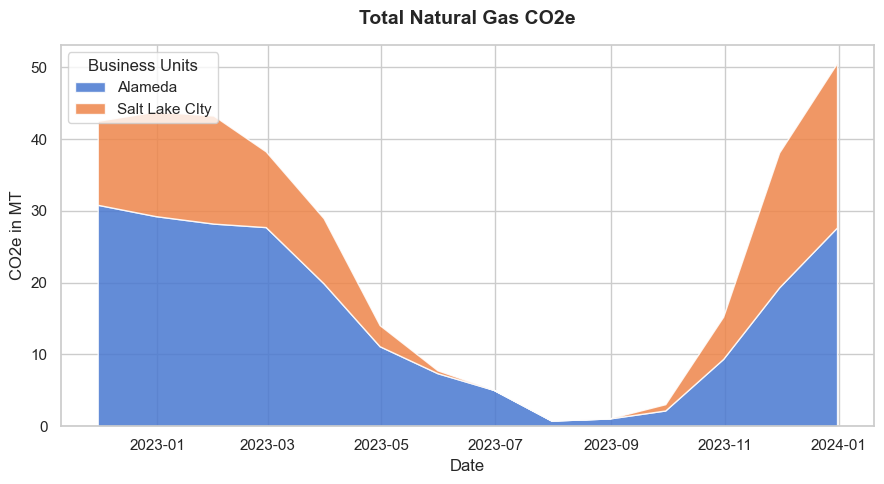

<Figure size 640x480 with 0 Axes>

In [23]:

# 1. Activate Seaborn styling
sns.set_theme(style="whitegrid")

# 3. Choose a Seaborn color palette
colors = sns.color_palette("muted", 3)

# 4. Create the plot
fig, ax = plt.subplots(figsize=(9, 5))

ax.stackplot(
    ghg_co2e_2023['date'], 
    ghg_co2e_2023['al_dk_co2'], ghg_co2e_2023['slc_total_co2'], 
    labels=['Alameda', 'Salt Lake CIty'],
    colors=colors,
    alpha=0.85
)

# 5. Clean up annotations using Matplotlib
ax.set_title("Total Natural Gas CO2e", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Date")
ax.set_ylabel("CO2e in MT")
ax.legend(title="Business Units", loc='upper left')

plt.tight_layout()
plt.show()
plt.savefig(
    "/Users/noracook/sustainability_projects/checkerspot/na_stacked_chart.png",  # File name and extension (.png, .jpg, .pdf, .svg)
    dpi=300,  # High resolution for crisp printing/presentations
    bbox_inches="tight",  # Automatically prevents cut-off legends or axis labels
)

In [24]:
#create a ne excel file called outputs and put the merged dk dataframe onto a tab called 2023 Scope 1
file_path = r'C:\Users\noracook\sustainability_projects\checkerspot\checkerspot\outputs.xlsx'

# 2. FORCE write mode ('w') to overwrite the corrupted file completely
with pd.ExcelWriter(file_path, mode='w') as writer:
    merged_dk.to_excel(writer, sheet_name='2023 Scope 1', index=False)



## Scope 2 Emissions

### Electricity

#### Let's create a dataframe for Alameda HQ's Electricity Usage

In [25]:
# Directory path configurations
pdf_directory = "/Users/noracook/sustainability_projects/checkerspot/Alameda_Electric only_AMP"  
pdf_pattern = os.path.join(pdf_directory, "*.[pP][dD][fF]")

# Regular expressions for cleaning and metric tracking
cid_pattern = r"\(cid:(\d+)\)"
kwh_regex = r"([\d,.]+)\s*kWh"

parsed_rows = []

def decode_cid_text(text):
    """
    Finds all occurrences of (cid:XXX) in a string and 
    converts the decimal number back into a readable character.
    """
    if not text:
        return ""
        
    def replace_cid(match):
        cid_val = int(match.group(1))
        try:
            return chr(cid_val)
        except ValueError:
            return match.group(0)  # Return unchanged if it cannot map
            
    return re.sub(cid_pattern, replace_cid, text)


# Loop through all matching PDFs found in the directory
for pdf_path in glob.glob(pdf_pattern):
    base_name = os.path.basename(pdf_path)
    extracted_floats = []
    
    # Extract only the first 6 characters for the clean prefix
    file_prefix = re.sub(r'\.pdf$', '', base_name, flags=re.IGNORECASE).replace(' ', '_')
    short_prefix = file_prefix[:6]
    variable_name = f"{short_prefix}"
    
    try:
        with pdfplumber.open(pdf_path) as pdf:
            full_text = ""
            for page in pdf.pages:
                raw_text = page.extract_text() or ""
                # CRITICAL STEP: Convert CIDs to real numbers and letters
                clean_page_text = decode_cid_text(raw_text)
                full_text += clean_page_text + "\n"
        
        # Flatten spaces/tabs to normalize formatting differences
        full_text = re.sub(r'[ \t]+', ' ', full_text)
        
        # Run your standard pattern against the newly translated clean text string
        matches = re.findall(kwh_regex, full_text, re.IGNORECASE)
        for match in matches:
            clean_match = match.replace(",", "")
            extracted_floats.append(float(clean_match))
            
        # Total sum of kWh, or fall back to 2.5 if empty
        total_kwh = sum(extracted_floats) if extracted_floats else 2.5
        
        # Set standalone dynamic global variable fallback
        globals()[variable_name] = total_kwh
        
        # Append data as a dictionary row
        parsed_rows.append({
            "variable_name": variable_name,
            "kwh_value": total_kwh
        })
        
    except Exception as e:
        print(f"Error processing {short_prefix}: {e}")

# --- CONVERT TO DATAFRAME & PRINT ---
df_electricity_al = pd.DataFrame(parsed_rows)


In [26]:
# change the invoice_prefix to a date
df_electricity_al['variable_name'] = pd.to_datetime(df_electricity_al['variable_name'], format='%y%m%d')

df_electricity_al = df_electricity_al.rename(columns={"variable_name":"date","kwh_value":"al_kWh"})
df_electricity_al

,date,al_kWh
0,2024-01-24,21520.0
1,2023-05-23,15520.0
2,2023-06-20,12960.0
3,2023-01-24,20320.0
4,2023-07-19,12240.0
5,2023-03-21,20600.0
6,2023-12-18,18280.0
7,2023-02-21,19600.0
8,2022-12-27,22840.0
9,2023-10-18,10880.0


In [27]:
df_electricity_al = df_electricity_al.sort_values(by="date")
df_electricity_al

,date,al_kWh
8,2022-12-27,22840.0
3,2023-01-24,20320.0
7,2023-02-21,19600.0
5,2023-03-21,20600.0
11,2023-04-19,19880.0
1,2023-05-23,15520.0
2,2023-06-20,12960.0
4,2023-07-19,12240.0
12,2023-08-21,11080.0
10,2023-09-18,11160.0


In [28]:
def align_to_billing_month(date_val, threshold_day=5):
    """
    Shifts dates to the last day of their corresponding billing month.
    If the date is on or before the 'threshold_day' (e.g., the 5th), 
    it rolls back to the last day of the previous month.
    """
    ts = pd.to_datetime(date_val)
    if pd.isna(ts):
        return pd.NaT
        
    # If it's early in the month (e.g., Nov 2nd), roll back to previous month's end (Oct 31)
    if ts.day <= threshold_day:
        return ts - pd.offsets.MonthEnd(1)
    else:
        # Otherwise, snap to the end of the current month (Nov 30)
        return ts + pd.offsets.MonthEnd(0)

# --- HOW TO APPLY TO YOUR DATAFRAME ---

# 1. Convert your date column to datetime objects first
df_electricity_al['date'] = pd.to_datetime(df_electricity_al['date'])

# 2. Apply the function to the date column
df_electricity_al['date'] = df_electricity_al['date'].apply(align_to_billing_month, threshold_day=5)

In [29]:
df_electricity_al

,date,al_kWh
8,2022-12-31,22840.0
3,2023-01-31,20320.0
7,2023-02-28,19600.0
5,2023-03-31,20600.0
11,2023-04-30,19880.0
1,2023-05-31,15520.0
2,2023-06-30,12960.0
4,2023-07-31,12240.0
12,2023-08-31,11080.0
10,2023-09-30,11160.0


In [30]:
df_electricity_al.to_excel('/Users/noracook/sustainability_projects/checkerspot/outputs/alameda_electricity_data.xlsx', index=False)

#### Let's create a dataframe for Salt Lake City's Electricity Usage

In [31]:
# Directory path configurations
pdf_directory = "/Users/noracook/sustainability_projects/checkerspot/SLC_Electric_RMP"  
pdf_pattern = os.path.join(pdf_directory, "*.[pP][dD][fF]")

kwh_regex = r"(?:29|1\.0)\s+([\d,]+)\s*kwh"
parsed_rows = []  # Explicitly reset or ensure your collection list is ready

# Loop through all matching PDFs found in the directory
for pdf_path in glob.glob(pdf_pattern):
    base_name = os.path.basename(pdf_path)
    extracted_floats = []
    
    # Extract only the first 6 characters for the clean prefix
    file_prefix = re.sub(r'\.pdf$', '', base_name, flags=re.IGNORECASE).replace(' ', '_')
    short_prefix = file_prefix[:6]
    variable_name = f"{short_prefix}"
    
    try:
        with pdfplumber.open(pdf_path) as pdf:
            full_text = ""
            for page in pdf.pages:
                raw_text = page.extract_text() or ""
                full_text += raw_text + "\n"
        
        # Flatten spaces/tabs to normalize formatting differences
        full_text = re.sub(r'[ \t]+', ' ', full_text)

        matches = re.findall(kwh_regex, full_text, re.IGNORECASE)
        for match in matches:
            clean_match = match.replace(",", "")
            extracted_floats.append(float(clean_match))
            
        extracted_floats = list(set(extracted_floats))
        print(f"{short_prefix}: {extracted_floats}")

        
        # Total sum of kWh, or fall back to 2.5 if empty
        total_kwh = sum(extracted_floats) if extracted_floats else 2.5
        
        # Set standalone dynamic global variable fallback
        globals()[variable_name] = total_kwh
        
       # 1. Start building the row dictionary
        row_dict = {
            "variable_name": variable_name,
            "total_kwh_value": total_kwh
        }
        
        # 2. FIX: Unpack the list items into separate keys dynamically
        for i, val in enumerate(extracted_floats, start=1):
            row_dict[f"extracted_kwh_{i}"] = val
            
        # 3. Append the expanded dictionary straight to your rows list
        parsed_rows.append(row_dict)
        
    except Exception as e:
        print(f"Error processing {short_prefix}: {e}")

# --- CONVERT TO DATAFRAME & PRINT ---
df_electricity_slc = pd.DataFrame(parsed_rows)

230906: [1696.0, 22816.0, 4986.0, 1047.0]
221230: [2608.0, 8993.0, 741.0, 4110.0]
230807: [2050.0, 4403.0, 23900.0, 1620.0]
230301: [4408.0, 760.0, 6952.0, 2645.0]
230131: [811.0, 4132.0, 2909.0, 7395.0]
240101: [4466.0, 2050.0, 844.0, 10479.0]
231030: [729.0, 883.0, 9780.0, 4661.0]
230629: [1304.0, 1576.0, 11948.0, 4159.0]
231201: [5370.0, 1667.0, 10949.0, 1007.0]
230530: [914.0, 4187.0, 14357.0, 1390.0]
231005: [1163.0, 788.0, 4781.0, 16347.0]
230330: [2088.0, 6899.0, 5157.0, 710.0]
230505: [609.0, 8467.0, 4014.0, 1953.0]


In [32]:
df_electricity_slc

,variable_name,total_kwh_value,extracted_kwh_1,extracted_kwh_2,extracted_kwh_3,extracted_kwh_4
0,230906,30545.0,1696.0,22816.0,4986.0,1047.0
1,221230,16452.0,2608.0,8993.0,741.0,4110.0
2,230807,31973.0,2050.0,4403.0,23900.0,1620.0
3,230301,14765.0,4408.0,760.0,6952.0,2645.0
4,230131,15247.0,811.0,4132.0,2909.0,7395.0
5,240101,17839.0,4466.0,2050.0,844.0,10479.0
6,231030,16053.0,729.0,883.0,9780.0,4661.0
7,230629,18987.0,1304.0,1576.0,11948.0,4159.0
8,231201,18993.0,5370.0,1667.0,10949.0,1007.0
9,230530,20848.0,914.0,4187.0,14357.0,1390.0


In [33]:
# change the invoice_prefix to a date
df_electricity_slc['variable_name'] = pd.to_datetime(df_electricity_slc['variable_name'], format='%y%m%d')

df_electricity_slc = df_electricity_slc.rename(columns={"variable_name":"date", "total_kwh_value":"slc_total_kWh"}, errors="ignore")
df_electricity_slc

,date,slc_total_kWh,extracted_kwh_1,extracted_kwh_2,extracted_kwh_3,extracted_kwh_4
0,2023-09-06,30545.0,1696.0,22816.0,4986.0,1047.0
1,2022-12-30,16452.0,2608.0,8993.0,741.0,4110.0
2,2023-08-07,31973.0,2050.0,4403.0,23900.0,1620.0
3,2023-03-01,14765.0,4408.0,760.0,6952.0,2645.0
4,2023-01-31,15247.0,811.0,4132.0,2909.0,7395.0
5,2024-01-01,17839.0,4466.0,2050.0,844.0,10479.0
6,2023-10-30,16053.0,729.0,883.0,9780.0,4661.0
7,2023-06-29,18987.0,1304.0,1576.0,11948.0,4159.0
8,2023-12-01,18993.0,5370.0,1667.0,10949.0,1007.0
9,2023-05-30,20848.0,914.0,4187.0,14357.0,1390.0


In [34]:
df_electricity_slc = df_electricity_slc.sort_values(by="date")
df_electricity_slc

,date,slc_total_kWh,extracted_kwh_1,extracted_kwh_2,extracted_kwh_3,extracted_kwh_4
1,2022-12-30,16452.0,2608.0,8993.0,741.0,4110.0
4,2023-01-31,15247.0,811.0,4132.0,2909.0,7395.0
3,2023-03-01,14765.0,4408.0,760.0,6952.0,2645.0
11,2023-03-30,14854.0,2088.0,6899.0,5157.0,710.0
12,2023-05-05,15043.0,609.0,8467.0,4014.0,1953.0
9,2023-05-30,20848.0,914.0,4187.0,14357.0,1390.0
7,2023-06-29,18987.0,1304.0,1576.0,11948.0,4159.0
2,2023-08-07,31973.0,2050.0,4403.0,23900.0,1620.0
0,2023-09-06,30545.0,1696.0,22816.0,4986.0,1047.0
10,2023-10-05,23079.0,1163.0,788.0,4781.0,16347.0


In [35]:
df_electricity_slc.to_excel('/Users/noracook/sustainability_projects/checkerspot/outputs/slc_electricity_data.xlsx', index=False)

In [36]:
def align_to_billing_month(date_val, threshold_day=5):
    """
    Shifts dates to the last day of their corresponding billing month.
    If the date is on or before the 'threshold_day' (e.g., the 5th), 
    it rolls back to the last day of the previous month.
    """
    ts = pd.to_datetime(date_val)
    if pd.isna(ts):
        return pd.NaT
        
    # If it's early in the month (e.g., Nov 2nd), roll back to previous month's end (Oct 31)
    if ts.day <= threshold_day:
        return ts - pd.offsets.MonthEnd(1)
    else:
        # Otherwise, snap to the end of the current month (Nov 30)
        return ts + pd.offsets.MonthEnd(0)

# --- HOW TO APPLY TO YOUR DATAFRAME ---

# 1. Convert your date column to datetime objects first
df_electricity_slc['date'] = pd.to_datetime(df_electricity_slc['date'])

# 2. Apply the function to the date column
df_electricity_slc['date'] = df_electricity_slc['date'].apply(align_to_billing_month, threshold_day=5)

In [37]:
df_electricity_slc

,date,slc_total_kWh,extracted_kwh_1,extracted_kwh_2,extracted_kwh_3,extracted_kwh_4
1,2022-12-31,16452.0,2608.0,8993.0,741.0,4110.0
4,2023-01-31,15247.0,811.0,4132.0,2909.0,7395.0
3,2023-02-28,14765.0,4408.0,760.0,6952.0,2645.0
11,2023-03-31,14854.0,2088.0,6899.0,5157.0,710.0
12,2023-04-30,15043.0,609.0,8467.0,4014.0,1953.0
9,2023-05-31,20848.0,914.0,4187.0,14357.0,1390.0
7,2023-06-30,18987.0,1304.0,1576.0,11948.0,4159.0
2,2023-08-31,31973.0,2050.0,4403.0,23900.0,1620.0
0,2023-09-30,30545.0,1696.0,22816.0,4986.0,1047.0
10,2023-09-30,23079.0,1163.0,788.0,4781.0,16347.0


In [38]:
# Selects just the 'date' and 'total_kwh_value' columns for ALL rows
df_elec_slc_total = df_electricity_slc[["date", "slc_total_kWh"]]

df_elec_slc_total

,date,slc_total_kWh
1,2022-12-31,16452.0
4,2023-01-31,15247.0
3,2023-02-28,14765.0
11,2023-03-31,14854.0
12,2023-04-30,15043.0
9,2023-05-31,20848.0
7,2023-06-30,18987.0
2,2023-08-31,31973.0
0,2023-09-30,30545.0
10,2023-09-30,23079.0


In [39]:
df_electricity = df_electricity_al.merge(df_elec_slc_total, on="date")
df_electricity["total_kWh"] = df_electricity["al_kWh"] + df_electricity["slc_total_kWh"]
df_electricity["al_MWh"]= df_electricity["al_kWh"]/1000
df_electricity["slc_MWh"] = df_electricity["slc_total_kWh"]/1000
df_electricity["total_MWh"] = df_electricity["al_MWh"] + df_electricity["slc_MWh"]
df_electricity

,date,al_kWh,slc_total_kWh,total_kWh,al_MWh,slc_MWh,total_MWh
0,2022-12-31,22840.0,16452.0,39292.0,22.84,16.452,39.292
1,2023-01-31,20320.0,15247.0,35567.0,20.32,15.247,35.567
2,2023-02-28,19600.0,14765.0,34365.0,19.60,14.765,34.365
3,2023-03-31,20600.0,14854.0,35454.0,20.60,14.854,35.454
4,2023-04-30,19880.0,15043.0,34923.0,19.88,15.043,34.923
5,2023-05-31,15520.0,20848.0,36368.0,15.52,20.848,36.368
6,2023-06-30,12960.0,18987.0,31947.0,12.96,18.987,31.947
7,2023-08-31,11080.0,31973.0,43053.0,11.08,31.973,43.053
8,2023-09-30,11160.0,30545.0,41705.0,11.16,30.545,41.705
9,2023-09-30,11160.0,23079.0,34239.0,11.16,23.079,34.239


In [40]:
df_electricity_mj= df_electricity[["al_MWh","slc_MWh","total_MWh"]] * 3600
df_electricity_mj = df_electricity_mj.rename(columns={"al_MWh":"al_elec_mj","slc_MWh":"slc_elec_mj","total_MWh":"total_elec_mj"})
df_electricity_mj

,al_elec_mj,slc_elec_mj,total_elec_mj
0,82224.0,59227.2,141451.2
1,73152.0,54889.2,128041.2
2,70560.0,53154.0,123714.0
3,74160.0,53474.4,127634.4
4,71568.0,54154.8,125722.8
5,55872.0,75052.8,130924.8
6,46656.0,68353.2,115009.2
7,39888.0,115102.8,154990.8
8,40176.0,109962.0,150138.0
9,40176.0,83084.4,123260.4


In [41]:
df_electricity.to_excel('/Users/noracook/sustainability_projects/checkerspot/outputs/total_electricity_data.xlsx', index=False)

In [42]:
electricity_co2_2022 = ghg_2022.iloc[311:339, 2:4]
# Rename specific columns and modify the DataFrame in place
electricity_co2_2022.rename(columns={'Unnamed: 2': 'eGRID subregion', 'Unnamed: 3': 'CO2 Factor lb/MWh'}, inplace=True)

electricity_co2_2022

,eGRID subregion,CO2 Factor lb/MWh
311,AKGD (ASCC Alaska Grid),1097.6
312,AKMS (ASCC Miscellaneous),534.1
313,AZNM (WECC Southwest),846.6
314,CAMX (WECC California),513.5
315,ERCT (ERCOT All),818.6
316,FRCC (FRCC All),835.1
317,HIMS (HICC Miscellaneous),1143.2
318,HIOA (HICC Oahu),1653
319,MROE (MRO East),1526.4
320,MROW (MRO West),979.5


In [43]:
# 1. Replace 'Region' with the exact name of the column that contains 'CAMX (WECC California)'
electricity_co2_2022 = electricity_co2_2022.set_index('eGRID subregion')

row_idx = electricity_co2_2022.index.get_loc('CAMX (WECC California)')
al_co2_factor_2022 = electricity_co2_2022.iloc[row_idx, 0]

row_idx = electricity_co2_2022.index.get_loc('NWPP (WECC Northwest)')
slc_co2_factor_2022 = electricity_co2_2022.iloc[row_idx, 0]

print("California 2022 CO2 emissions factor: ",al_co2_factor_2022)
print("Utah 2022 CO2 emissions factor: ",slc_co2_factor_2022)

California 2022 CO2 emissions factor:  513.5
Utah 2022 CO2 emissions factor:  600


In [44]:
electricity_co2_2023 = ghg_2023.iloc[323:351, 3:5]
# Rename specific columns and modify the DataFrame in place
electricity_co2_2023.rename(columns={'Unnamed: 3': 'eGRID subregion', 'Unnamed: 4': 'CO2 Factor lb/MWh'}, inplace=True)

electricity_co2_2023

,eGRID subregion,CO2 Factor lb/MWh
323,AKGD (ASCC Alaska Grid),1067.7
324,AKMS (ASCC Miscellaneous),485.2
325,AZNM (WECC Southwest),819.7
326,CAMX (WECC California),531.7
327,ERCT (ERCOT All),813.6
328,FRCC (FRCC All),832.9
329,HIMS (HICC Miscellaneous),1134.4
330,HIOA (HICC Oahu),1633.1
331,MROE (MRO East),1582.1
332,MROW (MRO West),995.8


In [45]:
# 1. Replace 'Region' with the exact name of the column that contains 'CAMX (WECC California)'
electricity_co2_2023 = electricity_co2_2023.set_index('eGRID subregion')

row_idx = electricity_co2_2022.index.get_loc('CAMX (WECC California)')
al_co2_factor_2023 = electricity_co2_2023.iloc[row_idx, 0]

row_idx = electricity_co2_2023.index.get_loc('NWPP (WECC Northwest)')
slc_co2_factor_2023 = electricity_co2_2023.iloc[row_idx, 0]

print("California 2023 CO2 emissions factor: ",al_co2_factor_2023)
print("Utah 2023 CO2 emissions factor: ",slc_co2_factor_2023)

California 2023 CO2 emissions factor:  531.7
Utah 2023 CO2 emissions factor:  634.6


In [46]:
electricity_co2_2024 = ghg_2024.iloc[331:351, 3:5]
# Rename specific columns and modify the DataFrame in place
electricity_co2_2024.rename(columns={'Unnamed: 3': 'eGRID subregion', 'Unnamed: 4': 'CO2 Factor lb/MWh'}, inplace=True)

electricity_co2_2024

,eGRID subregion,CO2 Factor lb/MWh
331,MROE (MRO East),1582.1
332,MROW (MRO West),995.8
333,NEWE (NPCC New England),539.4
334,NWPP (WECC Northwest),634.6
335,NYCW (NPCC NYC/Westchester),816.8
336,NYLI (NPCC Long Island),1210.9
337,NYUP (NPCC Upstate NY),233.1
338,PRMS (Puerto Rico Miscellaneous),1558
339,RFCE (RFC East),672.8
340,RFCM (RFC Michigan),1214.1


In [47]:
# 1. Replace 'Region' with the exact name of the column that contains 'CAMX (WECC California)'
electricity_co2_2024 = electricity_co2_2024.set_index('eGRID subregion')

row_idx = electricity_co2_2022.index.get_loc('CAMX (WECC California)')
al_co2_factor_2024 = electricity_co2_2024.iloc[row_idx, 0]

row_idx = electricity_co2_2023.index.get_loc('NWPP (WECC Northwest)')
slc_co2_factor_2024 = electricity_co2_2024.iloc[row_idx, 0]

print("California 2024 CO2 emissions factor: ",al_co2_factor_2024)
print("Utah 2024 CO2 emissions factor: ",slc_co2_factor_2024)

California 2024 CO2 emissions factor:  634.6
Utah 2024 CO2 emissions factor:  1158.9


In [48]:
# 1. Define your factors in a dictionary
co2_factors_al = {
    2022: al_co2_factor_2022,
    2023: al_co2_factor_2023,
    2024: al_co2_factor_2024
}

# 2. Extract the year
years = df_electricity['date'].dt.year

# 3. Save the actual factor as its own column
df_electricity['al_co2_factor'] = years.map(co2_factors_al)

#df_electricity

# 4. Calculate the final CO2 emissions using the new factor column
df_electricity['co2_lb_al'] = df_electricity["al_MWh"] * df_electricity["al_co2_factor"]
df_electricity

,date,al_kWh,slc_total_kWh,total_kWh,al_MWh,slc_MWh,total_MWh,al_co2_factor,co2_lb_al
0,2022-12-31,22840.0,16452.0,39292.0,22.84,16.452,39.292,513.5,11728.340
1,2023-01-31,20320.0,15247.0,35567.0,20.32,15.247,35.567,531.7,10804.144
2,2023-02-28,19600.0,14765.0,34365.0,19.60,14.765,34.365,531.7,10421.320
3,2023-03-31,20600.0,14854.0,35454.0,20.60,14.854,35.454,531.7,10953.020
4,2023-04-30,19880.0,15043.0,34923.0,19.88,15.043,34.923,531.7,10570.196
5,2023-05-31,15520.0,20848.0,36368.0,15.52,20.848,36.368,531.7,8251.984
6,2023-06-30,12960.0,18987.0,31947.0,12.96,18.987,31.947,531.7,6890.832
7,2023-08-31,11080.0,31973.0,43053.0,11.08,31.973,43.053,531.7,5891.236
8,2023-09-30,11160.0,30545.0,41705.0,11.16,30.545,41.705,531.7,5933.772
9,2023-09-30,11160.0,23079.0,34239.0,11.16,23.079,34.239,531.7,5933.772


In [49]:
# 1. Define your factors in a dictionary
co2_factors_slc = {
    2022: slc_co2_factor_2022,
    2023: slc_co2_factor_2023,
    2024: slc_co2_factor_2024
}

# 2. Extract the year
years = df_electricity['date'].dt.year

# 3. Save the actual factor as its own column
df_electricity['slc_co2_factor'] = years.map(co2_factors_slc)

# 4. Calculate the final CO2 emissions using the new factor column
df_electricity['co2_lb_slc'] = df_electricity["slc_MWh"] * df_electricity['slc_co2_factor']
df_electricity["total_lb_co2"] = df_electricity["co2_lb_al"] + df_electricity["co2_lb_slc"]
df_electricity

,date,al_kWh,slc_total_kWh,total_kWh,al_MWh,slc_MWh,total_MWh,al_co2_factor,co2_lb_al,slc_co2_factor,co2_lb_slc,total_lb_co2
0,2022-12-31,22840.0,16452.0,39292.0,22.84,16.452,39.292,513.5,11728.340,600.0,9871.2000,21599.5400
1,2023-01-31,20320.0,15247.0,35567.0,20.32,15.247,35.567,531.7,10804.144,634.6,9675.7462,20479.8902
2,2023-02-28,19600.0,14765.0,34365.0,19.60,14.765,34.365,531.7,10421.320,634.6,9369.8690,19791.1890
3,2023-03-31,20600.0,14854.0,35454.0,20.60,14.854,35.454,531.7,10953.020,634.6,9426.3484,20379.3684
4,2023-04-30,19880.0,15043.0,34923.0,19.88,15.043,34.923,531.7,10570.196,634.6,9546.2878,20116.4838
5,2023-05-31,15520.0,20848.0,36368.0,15.52,20.848,36.368,531.7,8251.984,634.6,13230.1408,21482.1248
6,2023-06-30,12960.0,18987.0,31947.0,12.96,18.987,31.947,531.7,6890.832,634.6,12049.1502,18939.9822
7,2023-08-31,11080.0,31973.0,43053.0,11.08,31.973,43.053,531.7,5891.236,634.6,20290.0658,26181.3018
8,2023-09-30,11160.0,30545.0,41705.0,11.16,30.545,41.705,531.7,5933.772,634.6,19383.8570,25317.6290
9,2023-09-30,11160.0,23079.0,34239.0,11.16,23.079,34.239,531.7,5933.772,634.6,14645.9334,20579.7054


In [50]:
#convert from lbs to MT
target_cols = [
    'co2_lb_al',
    'co2_lb_slc',
    'total_lb_co2',
]

# 2. Update ONLY these columns inside the dataframe (Keep the rest intact!)
df_electricity[target_cols] = df_electricity[target_cols] / 2204.62

df_electricity = df_electricity.rename(columns={'co2_lb_al': 'co2_MT_al', 'co2_lb_slc': 'co2_MT_slc', 'total_lb_co2': 'total_co2_MT'})

df_electricity


,date,al_kWh,slc_total_kWh,total_kWh,al_MWh,slc_MWh,total_MWh,al_co2_factor,co2_MT_al,slc_co2_factor,co2_MT_slc,total_co2_MT
0,2022-12-31,22840.0,16452.0,39292.0,22.84,16.452,39.292,513.5,5.319892,600.0,4.477506,9.797398
1,2023-01-31,20320.0,15247.0,35567.0,20.32,15.247,35.567,531.7,4.900683,634.6,4.388850,9.289533
2,2023-02-28,19600.0,14765.0,34365.0,19.60,14.765,34.365,531.7,4.727037,634.6,4.250106,8.977143
3,2023-03-31,20600.0,14854.0,35454.0,20.60,14.854,35.454,531.7,4.968212,634.6,4.275725,9.243937
4,2023-04-30,19880.0,15043.0,34923.0,19.88,15.043,34.923,531.7,4.794566,634.6,4.330128,9.124694
5,2023-05-31,15520.0,20848.0,36368.0,15.52,20.848,36.368,531.7,3.743041,634.6,6.001098,9.744139
6,2023-06-30,12960.0,18987.0,31947.0,12.96,18.987,31.947,531.7,3.125633,634.6,5.465409,8.591042
7,2023-08-31,11080.0,31973.0,43053.0,11.08,31.973,43.053,531.7,2.672223,634.6,9.203430,11.875653
8,2023-09-30,11160.0,30545.0,41705.0,11.16,30.545,41.705,531.7,2.691517,634.6,8.792380,11.483897
9,2023-09-30,11160.0,23079.0,34239.0,11.16,23.079,34.239,531.7,2.691517,634.6,6.643292,9.334808


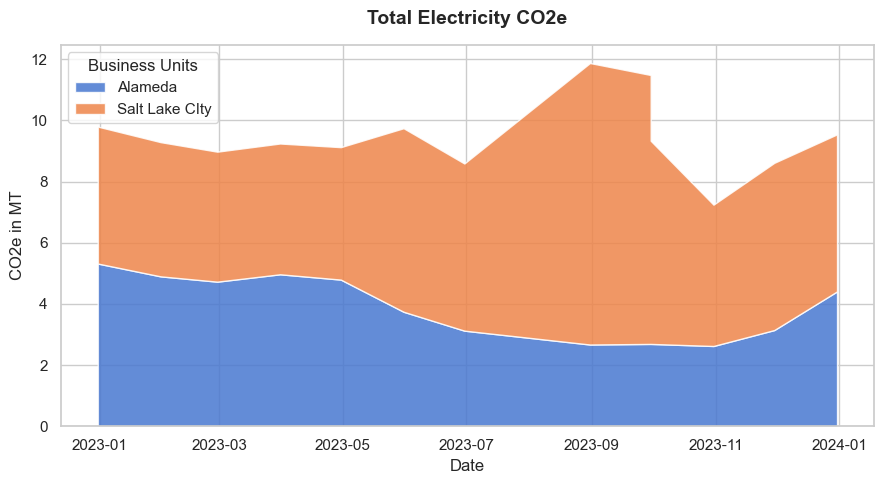

<Figure size 640x480 with 0 Axes>

In [51]:

# 1. Activate Seaborn styling
sns.set_theme(style="whitegrid")

# 3. Choose a Seaborn color palette
colors = sns.color_palette("muted", 3)

# 4. Create the plot
fig, ax = plt.subplots(figsize=(9, 5))

ax.stackplot(
    df_electricity['date'], 
    df_electricity['co2_MT_al'], df_electricity['co2_MT_slc'], 
    labels=['Alameda', 'Salt Lake CIty'],
    colors=colors,
    alpha=0.85
)

# 5. Clean up annotations using Matplotlib
ax.set_title("Total Electricity CO2e", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Date")
ax.set_ylabel("CO2e in MT")
ax.legend(title="Business Units", loc='upper left')

plt.tight_layout()
plt.show()
plt.savefig(
    "/Users/noracook/sustainability_projects/checkerspot/elec_stacked_chart.png",  # File name and extension (.png, .jpg, .pdf, .svg)
    dpi=300,  # High resolution for crisp printing/presentations
    bbox_inches="tight",  # Automatically prevents cut-off legends or axis labels
)

In [52]:
#create a ne excel file called outputs and put the merged dk dataframe onto a tab called 2023 Scope 2
file_path = r'C:\Users\noracook\sustainability_projects\checkerspot\checkerspot\outputs.xlsx'

# 2. FORCE write mode ('w') to overwrite the corrupted file completely
with pd.ExcelWriter(file_path, mode='w') as writer:
    df_electricity.to_excel(writer, sheet_name='2023 Scope 2', index=False)


## Scope 3 Emissions

### Waste

#### Let's create a dataframe for Alameda HQ waste and call it df_waste_al

In [53]:
import os
import glob
import re
import ocrmypdf
import pdfplumber
import pandas
from datetime import datetime

from pypdf import PdfReader

pdf_directory = "/Users/noracook/sustainability_projects/checkerspot/Alameda_Waste_ACI/old_invoices"
output_directory = "/Users/noracook/sustainability_projects/checkerspot/Alameda_Waste_ACI/ocr_processed_pdfs"
pdf_pattern = os.path.join(pdf_directory, "*.[pP][dD][fF]")

# Just check the very first PDF found to diagnose the text layout
for pdf_path in glob.glob(pdf_pattern):
    base_name = os.path.basename(pdf_path)
    temp_ocr_path = os.path.join(output_directory, "ocr_" + base_name)
    
    # Run OCR if the file hasn't been created yet
    if not os.path.exists(temp_ocr_path):
        ocrmypdf.ocr(pdf_path, temp_ocr_path, deskew=True, force_ocr=True)
        
    reader = PdfReader(temp_ocr_path)
    print(f"\n=== INSPECTING TEXT FOR: {base_name} ===")
    
    for page_num, page in enumerate(reader.pages):
        text = page.extract_text() or ""
        for line in text.split("\n"):
            # If the line contains "ORG", print it out raw
            if re.search(r"ORG", line, re.IGNORECASE):
                print(f"[Page {page_num+1} Raw Line]: '{line}'")
    


=== INSPECTING TEXT FOR: 230131 ACI Trash 1.1-1.31.23 #47286 $1010.50.pdf ===
[Page 1 Raw Line]: 'Recyclables, Organics & Garbage. 510-483-1400 main'
[Page 1 Raw Line]: '01/01/23-01/31/23 96 GAL COMMERCIAL ORG N/C-WEEKLY 1.00 0.00 0.00'
[Page 1 Raw Line]: '01/01/23-01/31/23 ‘BACKYARD SVC-ORGANICS-WEEKLY _ 1.00 0.00 0.00'
[Page 1 Raw Line]: 'Recyclables, Organics & Garbage.'

=== INSPECTING TEXT FOR: 221231 ACI Trash 12.1-12.31-22 Checkerspot $1,010.49 #47286.pdf ===
[Page 1 Raw Line]: 'Recyclables, Organics & Garbage, 510-483-1400 main'
[Page 1 Raw Line]: '12/01/22-12/3 1/22 96 GAL COMMERCIAL ORG N/C-WEEKLY 1.00 0.00 0.00'
[Page 1 Raw Line]: '12/01/22-12/3 1/22 BACKYARD SVC -ORGANICS-WEEKLY _ 1.00 0,00 0.00'
[Page 1 Raw Line]: 'Recyclables, Organics & Garbage.'

=== INSPECTING TEXT FOR: 230331 ACI trash 3.1-3.31.23 $1010.49 #047286.pdf ===
[Page 1 Raw Line]: 'Recyclables, Organics & Garbage. 510-483-1400 main'
[Page 1 Raw Line]: '| 03/01/23-03/3 1/23 96 GAL COMMERCIAL ORG N/C-WEEKLY 1

Here we see that there is a problem with OCR readings. So we substitute th armel with 3 YD and 9 YO with 3 YDs etc

In [54]:
#These are for the older fromat waste invoices. Here is were we read the invoices and then create variables with the waste amounts

"""THis process creates an output folder named ocr_processed_pdfs that you kinda need for this code to do OCR. This line of code creates an output folder than
places the processed invoices into it. You can later delete this folder if you would like. I used the pdf directory as the
file path for the output directory"""
# 1. Clean folder path configurations
pdf_directory = "/Users/noracook/sustainability_projects/checkerspot/Alameda_Waste_ACI/old_invoices"
output_directory = "/Users/noracook/sustainability_projects/checkerspot/Alameda_Waste_ACI/ocr_processed_pdfs"

os.makedirs(output_directory, exist_ok=True)

# 2. Match both lowercase .pdf and uppercase .PDF extensions safely
pdf_pattern = os.path.join(pdf_directory, "*.[pP][dD][fF]")
parsed_data = []

# Loop through all PDFs found
for pdf_path in glob.glob(pdf_pattern):
    base_name = os.path.basename(pdf_path)
    
    # Clean the file extension case-insensitively
    file_prefix = re.sub(r"\.pdf$", "", base_name, flags=re.IGNORECASE).replace(" ", "_")
    short_prefix = file_prefix[:6]

    # Run OCR on the PDF if it doesn't exist yet
    temp_ocr_path = os.path.join(output_directory, "ocr_" + base_name)
    if not os.path.exists(temp_ocr_path):
        ocrmypdf.ocr(pdf_path, temp_ocr_path, deskew=True, force_ocr=True)

    # Extract text from the OCR'd PDF
    reader = PdfReader(temp_ocr_path)
    print(f"\n=== INSPECTING TEXT FOR: {base_name} ===")

    full_text = ""
    for page in reader.pages:
        text = page.extract_text()
        if text:
            # Flatten multiple spaces and tabs first
            text = re.sub(r'[ \t]+', ' ', text)
            
            # Clean common typos globally on the whole page text
            text = re.sub(r'\bYP\b', 'YD', text, flags=re.IGNORECASE)
            text = re.sub(r'POMMINGLED', 'COMMINGLED', text, flags=re.IGNORECASE)
            text = re.sub(r'9\s*YO', '3 YD', text, flags=re.IGNORECASE)
            text = re.sub(r'th\s*arme[ld]', '3 YD', text, flags=re.IGNORECASE)
            
            full_text += text + "\n"

    for line in full_text.split("\n"):
        if any(keyword in line.upper() for keyword in ["RECYCLING", "COMMINGLED", "1 YD", "GARBAGE"]):
            print(f"[Sanitized Line]: '{line}'")

    # Ultra-flexible variation-proof pattern
    garbage_match = re.search(r"(\d+)\s*YD\s*GARBAGE[^\d]+(\d+)[^\d]+(\d+\.\d+|\d+)", full_text, re.IGNORECASE)
    recycling_match = re.search(r"(\d+)\s*YD\s*COMMINGLED\s*RECYCLING-(\d+)\s*TIMES\s*[PF]ER\s*(\d+\.\d+|\d+)", full_text, re.IGNORECASE)

    
    organics_match = re.search(r"(\d+)\s*(GAL|YD)\s*COMMERCIAL\s*ORG\s*N/C\s*-\s*WEEKLY\s*(\d+\.\d+|\d+)", full_text, re.IGNORECASE)

    # --- STEP 3: Extract values with Fallback rules ---
    if garbage_match:
        volume = float(garbage_match.group(1))
        frequency = float(garbage_match.group(2))
        bins = float(garbage_match.group(3))
        garbage_amount = volume * frequency * bins
    else:
        garbage_amount = 3.0 * 1.0 * 1.0

    if recycling_match:
        rec_volume = float(recycling_match.group(1))
        rec_frequency = float(recycling_match.group(2))
        rec_bins = float(recycling_match.group(3))
    else:
        recycling_amount = 88
    recyclable_amount = rec_volume * rec_frequency * rec_bins
    

    if organics_match:
        org_volume = float(organics_match.group(1))   # This will now work!
        org_unit = organics_match.group(2).upper()    
        org_count = float(organics_match.group(3))
        
        if org_unit == "GAL":
            organics_amount = org_volume * org_count * 0.00495113
        
        else: 
            organics_amount = org_volume * org_count
        print(organics_amount)

    else:
        organics_amount = 88

    # Append to structured list
    parsed_data.append({
        "invoice_prefix": short_prefix,
        "garbage_cu_yd": garbage_amount,
        "recycling_cu_yd": recyclable_amount,
        "organics_cu_yd": organics_amount
    })

# --- CONVERT TO DATAFRAME & PRINT ---
df_waste_al = pd.DataFrame(parsed_data)
print("\n=== PARSED WASTE METRICS ===")
print(df_waste_al.to_string(index=False))

# Optional: export to CSV for easy spreadsheet use
# df_waste.to_csv("waste_metrics_summary.csv", index=False)


=== INSPECTING TEXT FOR: 230131 ACI Trash 1.1-1.31.23 #47286 $1010.50.pdf ===
[Sanitized Line]: 'Recyclables, Organics & Garbage. 510-483-1400 main'
[Sanitized Line]: '01/01/23-01/3 1/23 3 YD GARBAGE-2 TIMES PER WEEK. 1.00 1,092.51 1,092.51'
[Sanitized Line]: '0U/01/23-01/31/23 3 YD COMMINGLED RECYCLING-2 TIMES PER 1.00 874,00 874,00'
[Sanitized Line]: 'Recyclables, Organics & Garbage.'
0.47530848

=== INSPECTING TEXT FOR: 221231 ACI Trash 12.1-12.31-22 Checkerspot $1,010.49 #47286.pdf ===
[Sanitized Line]: 'Recyclables, Organics & Garbage, 510-483-1400 main'
[Sanitized Line]: '12/01/22-12/31/22 3 YD GARBAGE-2 TIMES PER WEEK 1.00 1,092.51 1,092.51'
[Sanitized Line]: '12/0122-12/31/22 3 YD COMMINGLED RECYCLING-2 TIMES FER 1.00 874.00 874,00'
[Sanitized Line]: 'Recyclables, Organics & Garbage.'
0.47530848

=== INSPECTING TEXT FOR: 230331 ACI trash 3.1-3.31.23 $1010.49 #047286.pdf ===
[Sanitized Line]: 'Recyclables, Organics & Garbage. 510-483-1400 main'
[Sanitized Line]: '03/01/23-03/31

In [55]:
df_waste_al


,invoice_prefix,garbage_cu_yd,recycling_cu_yd,organics_cu_yd
0,230131,6.0,6.0,0.475308
1,221231,6.0,6.0,0.475308
2,230331,6.0,6.0,0.475308
3,230228,6.0,6.0,0.475308


In [56]:

# 1. Clean folder path
pdf_directory = "/Users/noracook/sustainability_projects/checkerspot/Alameda_Waste_ACI/new_invoices"
output_directory = "/Users/noracook/sustainability_projects/checkerspot/Alameda_Waste_ACI/ocr_processed_pdfs"

os.makedirs(output_directory, exist_ok=True)

# List to hold the newly parsed invoice data
new_parsed_data = []

# 2. Match both lowercase .pdf and uppercase .PDF extensions safely
pdf_pattern = os.path.join(pdf_directory, "*.[pP][dD][fF]")

# Loop through all PDFs found
for pdf_path in glob.glob(pdf_pattern):
    base_name = os.path.basename(pdf_path)
    
    # Clean the file extension case-insensitively
    file_prefix = re.sub(r"\.pdf$", "", base_name, flags=re.IGNORECASE).replace(" ", "_")
    
    # Extract only the first 6 characters of the prefix
    short_prefix = file_prefix[:6]
    
    # Run OCR on the PDF
    temp_ocr_path = os.path.join(output_directory, "ocr_" + base_name)
    ocrmypdf.ocr(pdf_path, temp_ocr_path, deskew=True, force_ocr=True)
    
    # Extract text from the OCR'd PDF
    reader = PdfReader(temp_ocr_path)
    full_text = ""
    for page in reader.pages:
        text = page.extract_text()
        if text:
            full_text += text + "\n"
            
    # Use Regular Expressions to find amount values (New Format Patterns)
    garbage_match = re.search(r"(\d+(?:\.\d+)?)\s*YD\s*GARBAGE\s*-\s*(\d+)X/WEEK\s*(\d+(?:\.\d+)?)", full_text, re.IGNORECASE)

    recycling_match = re.search(r"(\d+)\s*YD\s*COMMINGLED\s*RECYCLING\s*-\s*(\d+)X/WEEK\s*(\d+)", full_text, re.IGNORECASE)
    organics_match = re.search(r"(\d+)\s*(GAL|YD)\s*COMMERCIAL\s*ORG\s*N/C\s*-\s*WEEKLY\s*(\d+)", full_text, re.IGNORECASE)
        
    # Extract values and clean up string to float
    if garbage_match:
        volume = float(garbage_match.group(1))     
        frequency = float(garbage_match.group(2))  
        bins = float(garbage_match.group(3)) 
        garbage_amount = volume * frequency * bins
    else:
        # If no match is found, fallback to default dimensions
        garbage_amount = 88
        
    if recycling_match:
        rec_volume = float(recycling_match.group(1))
        rec_frequency = float(recycling_match.group(2))
        rec_bins = float(recycling_match.group(3))
    else:
        # If no match is found, fallback to default dimensions
        rec_volume = 3.0
        rec_frequency = 2.0
        rec_bins = 1.0
    recyclable_amount = rec_volume * rec_frequency * rec_bins

    if organics_match:
        org_volume = float(organics_match.group(1))
        org_unit = organics_match.group(2).upper()
        if org_unit == "GAL":
            organics_amount = org_volume * 0.00495113
        else:
            organics_amount = org_volume  
    else:
        organics_amount = 0.00495113
                  
    # Append the new row to our temporary list
    new_parsed_data.append({
        "invoice_prefix": short_prefix,
        "garbage_cu_yd": garbage_amount,
        "recycling_cu_yd": recyclable_amount,
        "organics_cu_yd": organics_amount
    })

# 3. Convert the new batch into a temporary DataFrame
df_new_invoices = pd.DataFrame(new_parsed_data)

# 4. Append new parsed data to the existing df_waste DataFrame
# (Assumes df_waste already exists from your previous code execution)
df_waste_al = pd.concat([df_waste_al, df_new_invoices], ignore_index=True)

# Optional: Avoid duplicate rows if you accidentally run the script twice
# df_waste = df_waste.drop_duplicates(subset=["invoice_prefix"], keep="last")

# --- CONVERT TO DATAFRAME & PRINT ---
print("\n=== PARSED WASTE METRICS (UPDATED COMBINED DATAFRAME) ===")
print(df_waste_al.to_string(index=False))



Output()

Output()

Output()

Output()

Output()

...

Output()

Output()

Output()

Output()


=== PARSED WASTE METRICS (UPDATED COMBINED DATAFRAME) ===
invoice_prefix  garbage_cu_yd  recycling_cu_yd  organics_cu_yd
        230131            6.0              6.0        0.475308
        221231            6.0              6.0        0.475308
        230331            6.0              6.0        0.475308
        230228            6.0              6.0        0.475308
        231031            6.0              9.0        0.475308
        240131            6.0              9.0        0.475308
        230831            6.0              9.0        0.475308
        231130            6.0              9.0        0.475308
        230630            6.0              6.0        0.475308
        231231            6.0              9.0        0.475308
        230731            6.0              6.0        0.475308
        230930            6.0              9.0        0.475308
        230430            6.0              6.0        0.475308
        230531            6.0              6.0        0.475

In [57]:
df_waste_al


,invoice_prefix,garbage_cu_yd,recycling_cu_yd,organics_cu_yd
0,230131,6.0,6.0,0.475308
1,221231,6.0,6.0,0.475308
2,230331,6.0,6.0,0.475308
3,230228,6.0,6.0,0.475308
4,231031,6.0,9.0,0.475308
5,240131,6.0,9.0,0.475308
6,230831,6.0,9.0,0.475308
7,231130,6.0,9.0,0.475308
8,230630,6.0,6.0,0.475308
9,231231,6.0,9.0,0.475308


In [58]:
# change the invoice_prefix to a date
df_waste_al['invoice_prefix'] = pd.to_datetime(df_waste_al['invoice_prefix'], format='%y%m%d')
df_waste_al = df_waste_al.rename(columns={"invoice_prefix":"date"})
df_waste_al

,date,garbage_cu_yd,recycling_cu_yd,organics_cu_yd
0,2023-01-31,6.0,6.0,0.475308
1,2022-12-31,6.0,6.0,0.475308
2,2023-03-31,6.0,6.0,0.475308
3,2023-02-28,6.0,6.0,0.475308
4,2023-10-31,6.0,9.0,0.475308
5,2024-01-31,6.0,9.0,0.475308
6,2023-08-31,6.0,9.0,0.475308
7,2023-11-30,6.0,9.0,0.475308
8,2023-06-30,6.0,6.0,0.475308
9,2023-12-31,6.0,9.0,0.475308


In [59]:
df_waste_al = df_waste_al.sort_values(by="date")
df_waste_al["al_monthly_garbage"] = df_waste_al["garbage_cu_yd"] * 4.44
df_waste_al["al_monthly_recycling"] = df_waste_al["recycling_cu_yd"] * 4.44
df_waste_al["al_monthly_organics"] = df_waste_al["organics_cu_yd"] * 4.44
df_waste_al


,date,garbage_cu_yd,recycling_cu_yd,organics_cu_yd,al_monthly_garbage,al_monthly_recycling,al_monthly_organics
1,2022-12-31,6.0,6.0,0.475308,26.64,26.64,2.11037
0,2023-01-31,6.0,6.0,0.475308,26.64,26.64,2.11037
3,2023-02-28,6.0,6.0,0.475308,26.64,26.64,2.11037
2,2023-03-31,6.0,6.0,0.475308,26.64,26.64,2.11037
12,2023-04-30,6.0,6.0,0.475308,26.64,26.64,2.11037
13,2023-05-31,6.0,6.0,0.475308,26.64,26.64,2.11037
8,2023-06-30,6.0,6.0,0.475308,26.64,26.64,2.11037
10,2023-07-31,6.0,6.0,0.475308,26.64,26.64,2.11037
6,2023-08-31,6.0,9.0,0.475308,26.64,39.96,2.11037
11,2023-09-30,6.0,9.0,0.475308,26.64,39.96,2.11037


### Now we will create a dataframe for Salt Lake City's waste and call it df_waste_slc

In [60]:
# 1. Clean folder path
pdf_directory = "/Users/noracook/sustainability_projects/checkerspot/SLC_Waste_Atlas/"


# List to hold the newly parsed invoice data
new_parsed_data = []

# 2. Match both lowercase .pdf and uppercase .PDF extensions safely
pdf_pattern = os.path.join(pdf_directory, "*.[pP][dD][fF]")

# Loop through all PDFs found
for pdf_path in glob.glob(pdf_pattern):
    base_name = os.path.basename(pdf_path)
    
    # Clean the file extension case-insensitively
    file_prefix = re.sub(r"\.pdf$", "", base_name, flags=re.IGNORECASE).replace(" ", "_")
    
    # Extract only the first 6 characters of the prefix
    short_prefix = file_prefix[:6]
    
    # --- NEW: CHECK IF PDF ALREADY HAS TEXT ---
    reader = PdfReader(pdf_path)
    full_text = ""
    for page in reader.pages:
        text = page.extract_text()
        if text:
            full_text += text + "\n"
            
    # Use Regular Expressions to find amount values (New Format Patterns)
    trash_pattern = r"(\d+)YD\s+TRASH\s+WEEKLY\s+SERVIC\s+#\s+P/U:\s+(\d+)\s+([\d.]+)"
    recycling_pattern = r"(\d+)\s*YD\s+RECYC\s+WKLY\s+SERVICE?\s*#\s*P/U:\s*(\d+)\s+([\d.]+)"

        
 # 1. Find ALL instances matching the pattern
    trash_matches = re.findall(trash_pattern, full_text, re.IGNORECASE)

# 2. Loop through and aggregate the values (FIXED INDENTATION MARGINS)
    if trash_matches:
        garbage_amount = 0.0  # Initialize the starting total at zero
    
        for match in trash_matches:
            volume = float(match[0])     # Captures container size (4 and 3)
            frequency = float(match[1])  # Captures pickup frequency (1 and 1)
            bins = float(match[2])       # Captures number of bins (1.00 and 1.00)
        
        # Adds ALL matches together inside the loop
            garbage_amount += (volume * frequency * bins)
    else:
    # This now correctly triggers ONLY if trash_matches is empty
        garbage_amount = 88.0 * 1.0 * 1.0

    recycling_match = re.search(trash_pattern, full_text, re.IGNORECASE)
    if recycling_match:
        rec_volume = float(recycling_match.group(1))     # Captures: 2.0
        rec_frequency = float(recycling_match.group(2))  # Captures: 1.0
        rec_bins = float(recycling_match.group(3))       # Captures: 1.00
    
        recyclable_amount = rec_volume * rec_frequency * rec_bins
    else:
        #if no match is found, fallback to default dimension
        recyclable_amount = 2.5
                  
    # Append the new row to our temporary list
    new_parsed_data.append({
        "invoice_prefix": short_prefix,
        "garbage_cu_yd": garbage_amount,
        "recycling_cu_yd": recyclable_amount,
    })

# 3. Convert the new batch into a temporary DataFrame
df_waste_slc = pd.DataFrame(new_parsed_data)

df_waste_slc



,invoice_prefix,garbage_cu_yd,recycling_cu_yd
0,230701,7.0,4.0
1,230201,7.0,4.0
2,230301,7.0,4.0
3,230601,7.0,4.0
4,231101,7.0,4.0
5,231001,7.0,4.0
6,240101,7.0,4.0
7,221201,7.0,4.0
8,230101,7.0,4.0
9,230801,7.0,4.0


In [61]:
# change the invoice_prefix to a date
df_waste_slc['invoice_prefix'] = pd.to_datetime(df_waste_slc['invoice_prefix'], format='%y%m%d')
df_waste_slc = df_waste_slc.rename(columns={"invoice_prefix":"date"})
df_waste_slc

,date,garbage_cu_yd,recycling_cu_yd
0,2023-07-01,7.0,4.0
1,2023-02-01,7.0,4.0
2,2023-03-01,7.0,4.0
3,2023-06-01,7.0,4.0
4,2023-11-01,7.0,4.0
5,2023-10-01,7.0,4.0
6,2024-01-01,7.0,4.0
7,2022-12-01,7.0,4.0
8,2023-01-01,7.0,4.0
9,2023-08-01,7.0,4.0


In [62]:
df_waste_slc = df_waste_slc.sort_values(by="date")
df_waste_slc["slc_monthly_garbage"] = df_waste_slc["garbage_cu_yd"] * 4.44
df_waste_slc["slc_monthly_recycling"] = df_waste_slc["recycling_cu_yd"] * 4.44
df_waste_slc

,date,garbage_cu_yd,recycling_cu_yd,slc_monthly_garbage,slc_monthly_recycling
7,2022-12-01,7.0,4.0,31.08,17.76
8,2023-01-01,7.0,4.0,31.08,17.76
1,2023-02-01,7.0,4.0,31.08,17.76
2,2023-03-01,7.0,4.0,31.08,17.76
11,2023-04-01,7.0,4.0,31.08,17.76
10,2023-05-01,7.0,4.0,31.08,17.76
3,2023-06-01,7.0,4.0,31.08,17.76
0,2023-07-01,7.0,4.0,31.08,17.76
9,2023-08-01,7.0,4.0,31.08,17.76
12,2023-09-01,7.0,4.0,31.08,17.76


In [63]:
df_waste_slc.to_excel('/Users/noracook/sustainability_projects/checkerspot/outputs/slc_waste.xlsx', index=False)

### We now have two databases for waste. One for Alameda, df_waste_al, and one for df_waste_slc. We will now merge the two and then create a new dataframe with just the monthly totals of waste streams for the combined dataframes

In [64]:
# 2. Extract Year-Month ('M') into temporary merge keys
df_waste_al['year_month'] = df_waste_al['date'].dt.to_period('M')
df_waste_slc['year_month'] = df_waste_slc['date'].dt.to_period('M')

# Merge using the new year_month column
merged_waste = pd.merge(df_waste_al, df_waste_slc, on='year_month', how='inner')

# 4. Optional: Clean up by dropping the temporary column afterward
merged_waste = merged_waste.drop(columns=['year_month'])

merged_waste

,date_x,garbage_cu_yd_x,recycling_cu_yd_x,organics_cu_yd,al_monthly_garbage,al_monthly_recycling,al_monthly_organics,date_y,garbage_cu_yd_y,recycling_cu_yd_y,slc_monthly_garbage,slc_monthly_recycling
0,2022-12-31,6.0,6.0,0.475308,26.64,26.64,2.11037,2022-12-01,7.0,4.0,31.08,17.76
1,2023-01-31,6.0,6.0,0.475308,26.64,26.64,2.11037,2023-01-01,7.0,4.0,31.08,17.76
2,2023-02-28,6.0,6.0,0.475308,26.64,26.64,2.11037,2023-02-01,7.0,4.0,31.08,17.76
3,2023-03-31,6.0,6.0,0.475308,26.64,26.64,2.11037,2023-03-01,7.0,4.0,31.08,17.76
4,2023-04-30,6.0,6.0,0.475308,26.64,26.64,2.11037,2023-04-01,7.0,4.0,31.08,17.76
5,2023-05-31,6.0,6.0,0.475308,26.64,26.64,2.11037,2023-05-01,7.0,4.0,31.08,17.76
6,2023-06-30,6.0,6.0,0.475308,26.64,26.64,2.11037,2023-06-01,7.0,4.0,31.08,17.76
7,2023-07-31,6.0,6.0,0.475308,26.64,26.64,2.11037,2023-07-01,7.0,4.0,31.08,17.76
8,2023-08-31,6.0,9.0,0.475308,26.64,39.96,2.11037,2023-08-01,7.0,4.0,31.08,17.76
9,2023-09-30,6.0,9.0,0.475308,26.64,39.96,2.11037,2023-09-01,7.0,4.0,31.08,17.76


In [65]:
merged_waste["total_monthly_garbage"] = merged_waste["al_monthly_garbage"] + merged_waste["slc_monthly_garbage"]
merged_waste["total_monthly_recycling"] = merged_waste["al_monthly_recycling"] + merged_waste["slc_monthly_recycling"]
merged_waste["total_monthly_organics"] = merged_waste["al_monthly_organics"]
# I am going to drop the date_y column because it turns out that SLC's waste management actually invoices for the month on the beggining 
# of the month unlike Alameda's waste management company that invoices at the end of the month
merged_waste = merged_waste.drop(columns=['date_y'], errors='ignore')
merged_waste = merged_waste.rename(columns={"date_x":"date",
                                          'garbage_cu_yd_x':"al_garbage_cu_yd",
                                          'recycling_cu_yd_x':"al_recycling_cu_yd",
                                          'organics_cu_yd':"al_organics_cu_yd",
                                          'garbage_cu_yd_y':"slc_garbage_cu_yd",
                                          'recycling_cu_yd_y':"slc_recycling_cu_yd"})

merged_waste

,date,al_garbage_cu_yd,al_recycling_cu_yd,al_organics_cu_yd,al_monthly_garbage,al_monthly_recycling,al_monthly_organics,slc_garbage_cu_yd,slc_recycling_cu_yd,slc_monthly_garbage,slc_monthly_recycling,total_monthly_garbage,total_monthly_recycling,total_monthly_organics
0,2022-12-31,6.0,6.0,0.475308,26.64,26.64,2.11037,7.0,4.0,31.08,17.76,57.72,44.40,2.11037
1,2023-01-31,6.0,6.0,0.475308,26.64,26.64,2.11037,7.0,4.0,31.08,17.76,57.72,44.40,2.11037
2,2023-02-28,6.0,6.0,0.475308,26.64,26.64,2.11037,7.0,4.0,31.08,17.76,57.72,44.40,2.11037
3,2023-03-31,6.0,6.0,0.475308,26.64,26.64,2.11037,7.0,4.0,31.08,17.76,57.72,44.40,2.11037
4,2023-04-30,6.0,6.0,0.475308,26.64,26.64,2.11037,7.0,4.0,31.08,17.76,57.72,44.40,2.11037
5,2023-05-31,6.0,6.0,0.475308,26.64,26.64,2.11037,7.0,4.0,31.08,17.76,57.72,44.40,2.11037
6,2023-06-30,6.0,6.0,0.475308,26.64,26.64,2.11037,7.0,4.0,31.08,17.76,57.72,44.40,2.11037
7,2023-07-31,6.0,6.0,0.475308,26.64,26.64,2.11037,7.0,4.0,31.08,17.76,57.72,44.40,2.11037
8,2023-08-31,6.0,9.0,0.475308,26.64,39.96,2.11037,7.0,4.0,31.08,17.76,57.72,57.72,2.11037
9,2023-09-30,6.0,9.0,0.475308,26.64,39.96,2.11037,7.0,4.0,31.08,17.76,57.72,57.72,2.11037


In [66]:
conversions = pd.read_excel(
    '/Users/noracook/sustainability_projects/checkerspot/Checkerspots Sustainablity Tables & Graphs_ 2018-2025 (KW Update 1-12).xlsx',
    sheet_name='2023')  # <-- This selects the specific tab

waste_conversions = conversions.iloc[132:138, 1:3]

waste_conversions

,Unnamed: 1,Unnamed: 2
132,Conversion: MT/lbs,0.000454
133,Gallons per cubic yard,173.569814
134,Lbs. per MT,2204.623
135,"Organics, lbs/yd^3 (EPA, 2016):",135
136,"Comingled Recycle, lbs/yd^3 (EPA, 2016):",262
137,"Comingled Trash, lbs/yd^3 (EPA, 2016):",138


In [67]:
# Grabs the raw number directly from the cell
conversion_factor_org = waste_conversions.iloc[3, 1]
conversion_factor_rec = waste_conversions.iloc[4, 1]
conversion_factor_gar = waste_conversions.iloc[5, 1]

# Multiply directly
merged_waste["al_total_monthly_garbage_lb"] = merged_waste["al_garbage_cu_yd"] * conversion_factor_gar
merged_waste["al_total_monthly_recycling_lb"] = merged_waste["al_recycling_cu_yd"] * conversion_factor_rec

merged_waste["slc_total_monthly_garbage_lb"] = merged_waste["slc_monthly_garbage"] * conversion_factor_gar
merged_waste["slc_total_monthly_recycling_lb"] = merged_waste["slc_monthly_recycling"] * conversion_factor_rec

merged_waste["total_monthly_organics_lb"] = merged_waste["total_monthly_organics"] * conversion_factor_org
merged_waste["total_monthly_recycling_lb"] = merged_waste["total_monthly_recycling"] * conversion_factor_rec
merged_waste["total_monthly_garbage_lb"] = merged_waste["total_monthly_garbage"] * conversion_factor_gar
merged_waste

,date,al_garbage_cu_yd,al_recycling_cu_yd,al_organics_cu_yd,al_monthly_garbage,al_monthly_recycling,al_monthly_organics,slc_garbage_cu_yd,slc_recycling_cu_yd,slc_monthly_garbage,...,total_monthly_garbage,total_monthly_recycling,total_monthly_organics,al_total_monthly_garbage_lb,al_total_monthly_recycling_lb,slc_total_monthly_garbage_lb,slc_total_monthly_recycling_lb,total_monthly_organics_lb,total_monthly_recycling_lb,total_monthly_garbage_lb
0,2022-12-31,6.0,6.0,0.475308,26.64,26.64,2.11037,7.0,4.0,31.08,...,57.72,44.40,2.11037,828.0,1572.0,4289.04,4653.12,284.899903,11632.80,7965.36
1,2023-01-31,6.0,6.0,0.475308,26.64,26.64,2.11037,7.0,4.0,31.08,...,57.72,44.40,2.11037,828.0,1572.0,4289.04,4653.12,284.899903,11632.80,7965.36
2,2023-02-28,6.0,6.0,0.475308,26.64,26.64,2.11037,7.0,4.0,31.08,...,57.72,44.40,2.11037,828.0,1572.0,4289.04,4653.12,284.899903,11632.80,7965.36
3,2023-03-31,6.0,6.0,0.475308,26.64,26.64,2.11037,7.0,4.0,31.08,...,57.72,44.40,2.11037,828.0,1572.0,4289.04,4653.12,284.899903,11632.80,7965.36
4,2023-04-30,6.0,6.0,0.475308,26.64,26.64,2.11037,7.0,4.0,31.08,...,57.72,44.40,2.11037,828.0,1572.0,4289.04,4653.12,284.899903,11632.80,7965.36
5,2023-05-31,6.0,6.0,0.475308,26.64,26.64,2.11037,7.0,4.0,31.08,...,57.72,44.40,2.11037,828.0,1572.0,4289.04,4653.12,284.899903,11632.80,7965.36
6,2023-06-30,6.0,6.0,0.475308,26.64,26.64,2.11037,7.0,4.0,31.08,...,57.72,44.40,2.11037,828.0,1572.0,4289.04,4653.12,284.899903,11632.80,7965.36
7,2023-07-31,6.0,6.0,0.475308,26.64,26.64,2.11037,7.0,4.0,31.08,...,57.72,44.40,2.11037,828.0,1572.0,4289.04,4653.12,284.899903,11632.80,7965.36
8,2023-08-31,6.0,9.0,0.475308,26.64,39.96,2.11037,7.0,4.0,31.08,...,57.72,57.72,2.11037,828.0,2358.0,4289.04,4653.12,284.899903,15122.64,7965.36
9,2023-09-30,6.0,9.0,0.475308,26.64,39.96,2.11037,7.0,4.0,31.08,...,57.72,57.72,2.11037,828.0,2358.0,4289.04,4653.12,284.899903,15122.64,7965.36


In [68]:
conversion_factor_lb_to_MT = waste_conversions.iloc[0, 1]
conversion_factor_lb_to_MT

0.0004535924

In [69]:
# Multiply directly
merged_waste["al_total_monthly_garbage_MT"] = merged_waste["al_total_monthly_garbage_lb"] * conversion_factor_lb_to_MT
merged_waste["al_total_monthly_recycling_MT"] = merged_waste["al_total_monthly_recycling_lb"] * conversion_factor_lb_to_MT

merged_waste["slc_total_monthly_garbage_MT"] = merged_waste["slc_total_monthly_garbage_lb"] * conversion_factor_lb_to_MT
merged_waste["slc_total_monthly_recycling_MT"] = merged_waste["slc_total_monthly_recycling_lb"] * conversion_factor_lb_to_MT


merged_waste["total_monthly_recycling_MT"] = merged_waste["total_monthly_recycling_lb"] * conversion_factor_lb_to_MT
merged_waste["total_monthly_garbage_MT"] = merged_waste["total_monthly_garbage_lb"] * conversion_factor_lb_to_MT
merged_waste["total_monthly_organics_MT"] = merged_waste["total_monthly_organics_lb"] * conversion_factor_lb_to_MT
merged_waste

,date,al_garbage_cu_yd,al_recycling_cu_yd,al_organics_cu_yd,al_monthly_garbage,al_monthly_recycling,al_monthly_organics,slc_garbage_cu_yd,slc_recycling_cu_yd,slc_monthly_garbage,...,total_monthly_organics_lb,total_monthly_recycling_lb,total_monthly_garbage_lb,al_total_monthly_garbage_MT,al_total_monthly_recycling_MT,slc_total_monthly_garbage_MT,slc_total_monthly_recycling_MT,total_monthly_recycling_MT,total_monthly_garbage_MT,total_monthly_organics_MT
0,2022-12-31,6.0,6.0,0.475308,26.64,26.64,2.11037,7.0,4.0,31.08,...,284.899903,11632.80,7965.36,0.375575,0.713047,1.945476,2.11062,5.276550,3.613027,0.129228
1,2023-01-31,6.0,6.0,0.475308,26.64,26.64,2.11037,7.0,4.0,31.08,...,284.899903,11632.80,7965.36,0.375575,0.713047,1.945476,2.11062,5.276550,3.613027,0.129228
2,2023-02-28,6.0,6.0,0.475308,26.64,26.64,2.11037,7.0,4.0,31.08,...,284.899903,11632.80,7965.36,0.375575,0.713047,1.945476,2.11062,5.276550,3.613027,0.129228
3,2023-03-31,6.0,6.0,0.475308,26.64,26.64,2.11037,7.0,4.0,31.08,...,284.899903,11632.80,7965.36,0.375575,0.713047,1.945476,2.11062,5.276550,3.613027,0.129228
4,2023-04-30,6.0,6.0,0.475308,26.64,26.64,2.11037,7.0,4.0,31.08,...,284.899903,11632.80,7965.36,0.375575,0.713047,1.945476,2.11062,5.276550,3.613027,0.129228
5,2023-05-31,6.0,6.0,0.475308,26.64,26.64,2.11037,7.0,4.0,31.08,...,284.899903,11632.80,7965.36,0.375575,0.713047,1.945476,2.11062,5.276550,3.613027,0.129228
6,2023-06-30,6.0,6.0,0.475308,26.64,26.64,2.11037,7.0,4.0,31.08,...,284.899903,11632.80,7965.36,0.375575,0.713047,1.945476,2.11062,5.276550,3.613027,0.129228
7,2023-07-31,6.0,6.0,0.475308,26.64,26.64,2.11037,7.0,4.0,31.08,...,284.899903,11632.80,7965.36,0.375575,0.713047,1.945476,2.11062,5.276550,3.613027,0.129228
8,2023-08-31,6.0,9.0,0.475308,26.64,39.96,2.11037,7.0,4.0,31.08,...,284.899903,15122.64,7965.36,0.375575,1.069571,1.945476,2.11062,6.859515,3.613027,0.129228
9,2023-09-30,6.0,9.0,0.475308,26.64,39.96,2.11037,7.0,4.0,31.08,...,284.899903,15122.64,7965.36,0.375575,1.069571,1.945476,2.11062,6.859515,3.613027,0.129228


In [70]:
waste_co2_factors_2022 = ghg_2022.iloc[398:459, 2:9]
first_row = waste_co2_factors_2022.iloc[0].tolist()
first_row
waste_co2_factors_2022 = waste_co2_factors_2022.rename(columns={"Unnamed: 2":'Material', "Unnamed: 3":"Recycled", "Unnamed: 4":"Landfilled",
                                                      "Unnamed: 5":"Combusted", "Unnamed: 6":"Composted",
                                                      "Unnamed: 7":'Anaerobically Digested (Dry Digestate with Curing)',
                                                      "Unnamed: 8":'Anaerobically Digested (Wet  Digestate with Curing)'})
waste_co2_factors_2022 = waste_co2_factors_2022.iloc[1:]

In [71]:
waste_co2_factors_2022

,Material,Recycled,Landfilled,Combusted,Composted,Anaerobically Digested (Dry Digestate with Curing),Anaerobically Digested (Wet Digestate with Curing)
399,Aluminum Cans,0.06,0.02,0.01,NaN,NaN,NaN
400,Aluminum Ingot,0.04,0.02,0.01,NaN,NaN,NaN
401,Steel Cans,0.32,0.02,0.01,NaN,NaN,NaN
402,Copper Wire,0.18,0.02,0.01,NaN,NaN,NaN
403,Glass,0.05,0.02,0.01,NaN,NaN,NaN
404,HDPE,0.21,0.02,2.8,NaN,NaN,NaN
405,LDPE,NaN,0.02,2.8,NaN,NaN,NaN
406,PET,0.23,0.02,2.05,NaN,NaN,NaN
407,LLDPE,NaN,0.02,2.8,NaN,NaN,NaN
408,PP,NaN,0.02,2.8,NaN,NaN,NaN


In [72]:
waste_co2_factors_2023 = ghg_2023.iloc[416:477, 2:9]
first_row = waste_co2_factors_2023.iloc[0].tolist()
first_row
waste_co2_factors_2023 = waste_co2_factors_2023.rename(columns={"Unnamed: 2":'Material', "Unnamed: 3":"Recycled", "Unnamed: 4":"Landfilled",
                                                      "Unnamed: 5":"Combusted", "Unnamed: 6":"Composted",
                                                      "Unnamed: 7":'Anaerobically Digested (Dry Digestate with Curing)',
                                                      "Unnamed: 8":'Anaerobically Digested (Wet  Digestate with Curing)'})
waste_co2_factors_2023 = waste_co2_factors_2023.iloc[1:]

In [73]:
waste_co2_factors_2023

,Material,Recycled,Landfilled,Combusted,Composted,Anaerobically Digested (Dry Digestate with Curing),Anaerobically Digested (Wet Digestate with Curing)
417,Aluminum Cans,0.06,0.02,0.01,NaN,NaN,NaN
418,Aluminum Ingot,0.04,0.02,0.01,NaN,NaN,NaN
419,Steel Cans,0.32,0.02,0.01,NaN,NaN,NaN
420,Copper Wire,0.18,0.02,0.01,NaN,NaN,NaN
421,Glass,0.05,0.02,0.01,NaN,NaN,NaN
422,HDPE,0.21,0.02,2.8,NaN,NaN,NaN
423,LDPE,NaN,0.02,2.8,NaN,NaN,NaN
424,PET,0.23,0.02,2.05,NaN,NaN,NaN
425,LLDPE,NaN,0.02,2.8,NaN,NaN,NaN
426,PP,NaN,0.02,2.8,NaN,NaN,NaN


In [74]:
waste_co2_factors_2022.to_excel('/Users/noracook/sustainability_projects/checkerspot/outputs/waste_co2_factors_2022.xlsx', index=False)

In [75]:
waste_co2_factors_2023.to_excel('/Users/noracook/sustainability_projects/checkerspot/outputs/waste_co2_factors_2023.xlsx', index=False)

In [76]:
# 1. Find the row where the first column equals "Mixed Organics"
# (Replace waste_co2_factors_2023.columns[0] with the actual column name if it has one)
mixed_org_row_2022 = waste_co2_factors_2022[waste_co2_factors_2022["Material"] == "Mixed Organics"]

# 2. Get columns index 2 and 3 using .iloc (positional slicing)
organics_co2_factor_2022 = mixed_org_row_2022.iloc[:, 4:5]
organics_co2_factor_2022

,Composted
439,0.17


In [77]:
# 1. Find the row where the first column equals "Mixed MSW"
mixed_gar_row_2022 = waste_co2_factors_2022[waste_co2_factors_2022["Material"] == "Mixed MSW"]

# 2. Get columns index 2 and 3 using .iloc (positional slicing)
garbage_co2_factor_2022 = mixed_gar_row_2022.iloc[:, 2:3]
garbage_co2_factor_2022

,Landfilled
440,0.52


In [78]:

# 1. Find the row where the first column equals "Mixed Recyclables"
# (Replace waste_co2_factors_2022.columns[0] with the actual column name if it has one)
mixed_rec_row_2022 = waste_co2_factors_2022[waste_co2_factors_2022["Material"] == "Mixed Recyclables"]

# 2. Get columns index 2 and 3 using .iloc (positional slicing)
recyclables_co2_factor_2022 = mixed_rec_row_2022.iloc[:, 1:2]
recyclables_co2_factor_2022 

,Recycled
437,0.09


In [79]:
# 1. Find the row where the first column equals "Mixed Organics"
# (Replace waste_co2_factors_2022.columns[0] with the actual column name if it has one)
mixed_org_row_2023 = waste_co2_factors_2023[waste_co2_factors_2023["Material"] == "Mixed Organics"]

# 2. Get columns index 2 and 3 using .iloc (positional slicing)
organics_co2_factor_2023 = mixed_org_row_2023.iloc[:, 4:5]
organics_co2_factor_2023 

,Composted
457,0.17


In [80]:
# 1. Find the row where the first column equals "Mixed MSW"
mixed_gar_row_2023 = waste_co2_factors_2023[waste_co2_factors_2023["Material"] == "Mixed MSW"]

# 2. Get columns index 2 and 3 using .iloc (positional slicing)
garbage_co2_factor_2023 = mixed_gar_row_2023.iloc[:, 2:3]
garbage_co2_factor_2023

,Landfilled
458,0.52


In [81]:

# 1. Find the row where the first column equals "Mixed Recyclables"
# (Replace waste_co2_factors_2022.columns[0] with the actual column name if it has one)
mixed_rec_row_2023 = waste_co2_factors_2023[waste_co2_factors_2023["Material"] == "Mixed Recyclables"]

# 2. Get columns index 2 and 3 using .iloc (positional slicing)
recyclables_co2_factor_2023 = mixed_rec_row_2023.iloc[:, 1:2]
recyclables_co2_factor_2023 

,Recycled
455,0.09


In [82]:
# Convert your factors into single numeric values (floats) 
# If they are still DataFrames, grab the very first element:
garbage_co2_val_2022 = float(garbage_co2_factor_2022.values.flatten()[0])
recyclables_co2_val_2022 = float(recyclables_co2_factor_2022.values.flatten()[0])
organics_co2_val_2022 = float(organics_co2_factor_2022.values.flatten()[0])

garbage_co2_val_2023 = float(garbage_co2_factor_2023.values.flatten()[0])
recyclables_co2_val_2023 = float(recyclables_co2_factor_2023.values.flatten()[0])
organics_co2_val_2023 = float(organics_co2_factor_2023.values.flatten()[0])

if  '2022' in merged_waste["date"]:
    merged_waste["al_total_monthly_garbage_co2e"] = merged_waste["al_total_monthly_garbage_MT"] * garbage_co2_val_2022
    merged_waste["al_total_monthly_recycling_co2e"] = merged_waste["al_total_monthly_garbage_MT"] * recyclables_co2_val_2022
    merged_waste["al_total_monthly_organics_co2e"] = merged_waste["total_monthly_organics_MT"] * organics_co2_val_2022

    merged_waste["slc_total_monthly_garbage_co2e"] = merged_waste["slc_total_monthly_garbage_MT"] * garbage_co2_val_2022
    merged_waste["slc_total_monthly_recycling_co2e"] = merged_waste["slc_total_monthly_recycling_MT"] * recyclables_co2_val_2022

    merged_waste["total_monthly_garbage_co2e"] = merged_waste["total_monthly_garbage_MT"] * garbage_co2_val_2022
    merged_waste["total_monthly_recycling_co2e"] = merged_waste["total_monthly_recycling_MT"] * recyclables_co2_val_2022
    merged_waste["total_monthly_organics_co2e"] = merged_waste["total_monthly_organics_MT"] * organics_co2_val_2022
    merged_waste["Total_waste_co2e"] = merged_waste["total_monthly_recycling_co2e"] + merged_waste["total_monthly_organics_co2e"] + merged_waste["total_monthly_garbage_co2e"]
    

    
else: 
    merged_waste["al_total_monthly_garbage_co2e"] = merged_waste["al_total_monthly_garbage_MT"] * garbage_co2_val_2023
    merged_waste["al_total_monthly_recycling_co2e"] = merged_waste["al_total_monthly_recycling_MT"] * recyclables_co2_val_2023
    merged_waste["al_total_monthly_organics_co2e"] = merged_waste["total_monthly_organics_MT"] * organics_co2_val_2023

    merged_waste["slc_total_monthly_garbage_co2e"] = merged_waste["slc_total_monthly_garbage_MT"] * garbage_co2_val_2023
    merged_waste["slc_total_monthly_recycling_co2e"] = merged_waste["slc_total_monthly_recycling_MT"] * recyclables_co2_val_2023

    merged_waste["total_monthly_garbage_co2e"] = merged_waste["total_monthly_garbage_MT"] * garbage_co2_val_2023
    merged_waste["total_monthly_recycling_co2e"] = merged_waste["total_monthly_recycling_MT"] * recyclables_co2_val_2023
    merged_waste["total_monthly_organics_co2e"] = merged_waste["total_monthly_organics_MT"] * organics_co2_val_2023

    merged_waste["Total_waste_co2e"] = merged_waste["total_monthly_recycling_co2e"] + merged_waste["total_monthly_organics_co2e"] + merged_waste["total_monthly_garbage_co2e"]
    
merged_waste



,date,al_garbage_cu_yd,al_recycling_cu_yd,al_organics_cu_yd,al_monthly_garbage,al_monthly_recycling,al_monthly_organics,slc_garbage_cu_yd,slc_recycling_cu_yd,slc_monthly_garbage,...,total_monthly_organics_MT,al_total_monthly_garbage_co2e,al_total_monthly_recycling_co2e,al_total_monthly_organics_co2e,slc_total_monthly_garbage_co2e,slc_total_monthly_recycling_co2e,total_monthly_garbage_co2e,total_monthly_recycling_co2e,total_monthly_organics_co2e,Total_waste_co2e
0,2022-12-31,6.0,6.0,0.475308,26.64,26.64,2.11037,7.0,4.0,31.08,...,0.129228,0.195299,0.064174,0.021969,1.011647,0.189956,1.878774,0.474889,0.021969,2.375632
1,2023-01-31,6.0,6.0,0.475308,26.64,26.64,2.11037,7.0,4.0,31.08,...,0.129228,0.195299,0.064174,0.021969,1.011647,0.189956,1.878774,0.474889,0.021969,2.375632
2,2023-02-28,6.0,6.0,0.475308,26.64,26.64,2.11037,7.0,4.0,31.08,...,0.129228,0.195299,0.064174,0.021969,1.011647,0.189956,1.878774,0.474889,0.021969,2.375632
3,2023-03-31,6.0,6.0,0.475308,26.64,26.64,2.11037,7.0,4.0,31.08,...,0.129228,0.195299,0.064174,0.021969,1.011647,0.189956,1.878774,0.474889,0.021969,2.375632
4,2023-04-30,6.0,6.0,0.475308,26.64,26.64,2.11037,7.0,4.0,31.08,...,0.129228,0.195299,0.064174,0.021969,1.011647,0.189956,1.878774,0.474889,0.021969,2.375632
5,2023-05-31,6.0,6.0,0.475308,26.64,26.64,2.11037,7.0,4.0,31.08,...,0.129228,0.195299,0.064174,0.021969,1.011647,0.189956,1.878774,0.474889,0.021969,2.375632
6,2023-06-30,6.0,6.0,0.475308,26.64,26.64,2.11037,7.0,4.0,31.08,...,0.129228,0.195299,0.064174,0.021969,1.011647,0.189956,1.878774,0.474889,0.021969,2.375632
7,2023-07-31,6.0,6.0,0.475308,26.64,26.64,2.11037,7.0,4.0,31.08,...,0.129228,0.195299,0.064174,0.021969,1.011647,0.189956,1.878774,0.474889,0.021969,2.375632
8,2023-08-31,6.0,9.0,0.475308,26.64,39.96,2.11037,7.0,4.0,31.08,...,0.129228,0.195299,0.096261,0.021969,1.011647,0.189956,1.878774,0.617356,0.021969,2.518099
9,2023-09-30,6.0,9.0,0.475308,26.64,39.96,2.11037,7.0,4.0,31.08,...,0.129228,0.195299,0.096261,0.021969,1.011647,0.189956,1.878774,0.617356,0.021969,2.518099


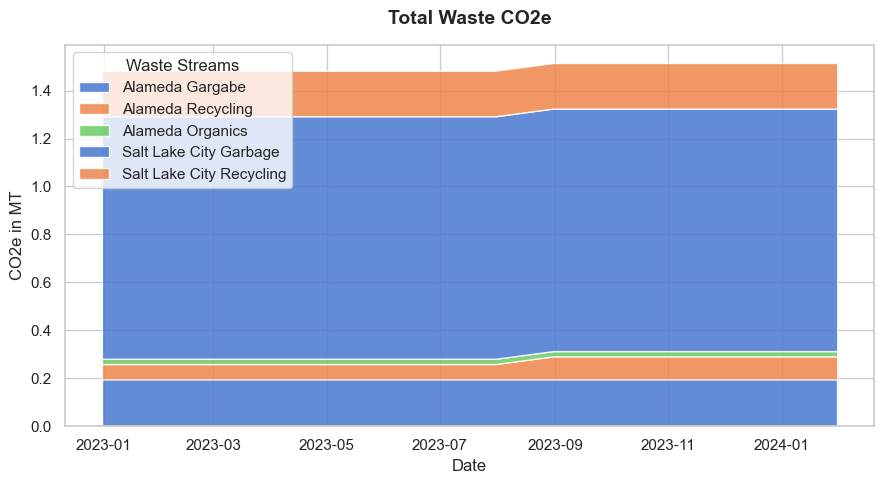

<Figure size 640x480 with 0 Axes>

In [83]:

# 1. Activate Seaborn styling
sns.set_theme(style="whitegrid")

# 3. Choose a Seaborn color palette
colors = sns.color_palette("muted", 3)

# 4. Create the plot
fig, ax = plt.subplots(figsize=(9, 5))

ax.stackplot(
    merged_waste['date'], 
    merged_waste['al_total_monthly_garbage_co2e'], merged_waste["al_total_monthly_recycling_co2e"],merged_waste["al_total_monthly_organics_co2e"], merged_waste['slc_total_monthly_garbage_co2e'], merged_waste["slc_total_monthly_recycling_co2e"],
    labels=['Alameda Gargabe','Alameda Recycling', 'Alameda Organics', 'Salt Lake City Garbage', 'Salt Lake City Recycling'],
    colors=colors,
    alpha=0.85
)

# 5. Clean up annotations using Matplotlib
ax.set_title("Total Waste CO2e", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Date")
ax.set_ylabel("CO2e in MT")
ax.legend(title="Waste Streams", loc='upper left')

plt.tight_layout()
plt.show()
plt.savefig(
    "/Users/noracook/sustainability_projects/checkerspot/elec_stacked_chart.png",  # File name and extension (.png, .jpg, .pdf, .svg)
    dpi=300,  # High resolution for crisp printing/presentations
    bbox_inches="tight",  # Automatically prevents cut-off legends or axis labels
)

# Total Scope 1, Scope2, & Scope 3 emissions

In [84]:
file_path = '/Users/noracook/sustainability_projects/checkerspot/carbon_footprint.xlsx'

# Open the writer cleanly
with pd.ExcelWriter(file_path, engine='openpyxl', mode='w') as writer:
    # Use your ACTUAL variable names here:
    ghg_co2e_2023.to_excel(writer, sheet_name='2023 Scope 1', index=False)
    df_electricity.to_excel(writer, sheet_name='2023 Scope 2', index=False)
    merged_waste.to_excel(writer, sheet_name='2023 Scope 3', index=False)



wb = openpyxl.load_workbook(file_path)

# Palettes: Muted Forest Green / Sustainability theme
header_fill = PatternFill(start_color="2D5A27", end_color="2D5A27", fill_type="solid")
header_font = Font(name="Arial", size=11, bold=True, color="FFFFFF")
data_font = Font(name="Arial", size=10)
bold_font = Font(name="Arial", size=10, bold=True)
thin_border = Border(
    left=Side(style='thin', color='E0E0E0'),
    right=Side(style='thin', color='E0E0E0'),
    top=Side(style='thin', color='E0E0E0'),
    bottom=Side(style='thin', color='E0E0E0')
)
zebra_fill = PatternFill(start_color="F7F9F6", end_color="F7F9F6", fill_type="solid")

for sheet_name in wb.sheetnames:
    ws = wb[sheet_name]
    ws.views.sheetView[0].showGridLines = True
    
    # Format Headers
    for cell in ws[1]:
        cell.fill = header_fill
        cell.font = header_font
        cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
    
    # Format Data Rows
    max_row = ws.max_row
    max_col = ws.max_column
    
    for row in range(2, max_row + 1):
        is_zebra = (row % 2 == 0)
        for col in range(1, max_col + 1):
            cell = ws.cell(row=row, column=col)
            cell.font = data_font
            cell.border = thin_border
            if is_zebra:
                cell.fill = zebra_fill
            
            # Alignments & Number formats
            if col == 1:
                cell.alignment = Alignment(horizontal="center")
            else:
                cell.alignment = Alignment(horizontal="right")
                cell.number_format = '#,##0.00'
                
    # Add a Total Row
    total_row_idx = max_row + 1
    ws.cell(row=total_row_idx, column=1, value="Total").font = bold_font
    ws.cell(row=total_row_idx, column=1).alignment = Alignment(horizontal="center")
    ws.cell(row=total_row_idx, column=1).border = Border(top=Side(style='thin', color='000000'), bottom=Side(style='double', color='000000'))
    
    for col in range(2, max_col + 1):
        col_letter = get_column_letter(col)
        total_cell = ws.cell(row=total_row_idx, column=col)
        total_cell.value = f"=SUM({col_letter}2:{col_letter}{max_row})"
        total_cell.font = bold_font
        total_cell.alignment = Alignment(horizontal="right")
        total_cell.number_format = '#,##0.00'
        total_cell.border = Border(top=Side(style='thin', color='000000'), bottom=Side(style='double', color='000000'))

    # Autofit columns
    for col in ws.columns:
        max_len = max(len(str(cell.value or '')) for cell in col)
        col_letter = get_column_letter(col[0].column)
        ws.column_dimensions[col_letter].width = max(max_len + 3, 12)

wb.save(file_path)
print("Successfully generated and styled Excel spreadsheet.")

Successfully generated and styled Excel spreadsheet.


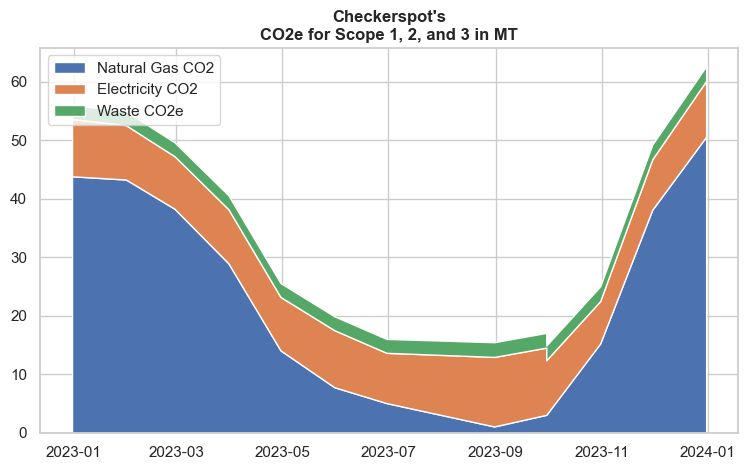

In [85]:
# 1. Merge the dataframes together based on the 'date' column
# This drops any mismatched rows so everything is the exact same length
plot_df = pd.merge(ghg_co2e_2023, df_electricity, on='date', how='inner')
plot_df = pd.merge(plot_df, merged_waste, on='date', how='inner')

# 1. Your plotting code
fig, ax = plt.subplots(figsize=(9, 5))
ax.stackplot(plot_df['date'], plot_df['total_co2'], plot_df['total_co2_MT'], plot_df['Total_waste_co2e'],
             labels=['Natural Gas CO2', 'Electricity CO2', 'Waste CO2e'])
ax.set_title("Checkerspot's\nCO2e for Scope 1, 2, and 3 in MT", fontsize=12, fontweight='bold')
ax.legend(loc='upper left')

# 2. SAVE FIRST 
plt.savefig('/Users/noracook/sustainability_projects/checkerspot/outputs/co2e_emissions_stackplot.png', dpi=300, bbox_inches='tight')

# 3. SHOW SECOND
plt.show()

In [86]:
plt.savefig('co2e_emissions_stackplot.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>